#Capstone 3: Predicting iPSC Donor Differentiation Success

I this project we will use iPSC scRNA-seq data from a dataset of 125 donors to predict endoderm differntiation efficiency. This dataset if from the publication

Cuomo, A.S.E., Seaton, D.D., McCarthy, D.J. *et al.*  
**Single-cell RNA-sequencing of differentiating iPS cells reveals dynamic genetic effects on gene expression.**  
*Nature Communications*, 11, 810 (2020).  
https://doi.org/10.1038/s41467-020-14457-z

The dataset can be dowloaded at: https://zenodo.org/record/3625024#.Xil-0y2cZ0s

The code used in this original publication can be found on Github: https://github.com/single-cell-genetics/singlecell_endodiff_paper/tree/main

##Loading Data

In this notebook we will build a predictive model using the scRNAseq counts from day0 cells (aka iPSCs prior to any differentiation) to predict the definitive endoderm (DE) score. This data can be found in the .h5ad file generated in the previous EDA notebook for this project and stored in the Google Drive foler Capstone3_iPSC_EDA.  There are two different DE scores that can be used as the target label, each with it's own dataset.

DEscore = Score derived from high expression of genes associated with endogenous definitive endoderm cells and low expression of genes associated with iPSCs, made using the `score_genes` function in the ScanPy library.

psuedorank = Score derived from the `psuedotime`, function in the ScanPy library which generates a progression from a randomly chosen day0 cell through the most differentiated cell in the dataset.

We'll start with mounting Google Drive, installing and importing the necessary libraries and loading the data files.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 54.8 gigabytes of available RAM

You are using a high-RAM runtime!


In [3]:
!pip install scanpy anndata seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 84.3 MB/s eta 0:00:00


In [4]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 25.2 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost.sklearn import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr, kendalltau
import shap
from collections import Counter
from catboost import Pool

In [6]:
day0_score = sc.read_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/Capstone3_iPSC_EDA/adata_DEscores_day0.h5ad")

##Convert Day0 data to Pseudobulk

As was shown in the previous notebook, building a predictive model from single cell data was not successfull as the learners focused on the noise in the data.  To address this, we will convert the data to psuedobulk with each donor being one sample.  The standard protocol is to sum the raw counts for each cell from a given donor.

In [151]:
#Code from https://www.youtube.com/watch?v=Ee0PQUwVH8Q
donors = []
for donor in day0_score.obs["donor"].unique():
  donor_day0 = day0_score[day0_score.obs["donor"] == donor].copy()
  donor_day0.X = donor_day0.layers["counts"] #Access the saved raw counts
  donor_rep = sc.AnnData(X = donor_day0.X.sum(axis=0).reshape(1, -1), var = donor_day0.var)
  donor_rep.obs_names = [donor]
  donor_rep.obs['DEscore_long'] = donor_day0.obs['mean_DEscore_long'].iloc[0]  #use our previously creates average scores from the day3 cells
  donor_rep.obs['DEscore_short'] = donor_day0.obs['mean_DEscore_short'].iloc[0]
  donor_rep.obs['pseudorank'] = donor_day0.obs['mean_pseudorank'].iloc[0]
  donors.append(donor_rep)
donor_adata = sc.concat(donors)

In [152]:
donor_day0.X.max()

np.float64(15974.7062116609)

In [153]:
#Verify our new dataset has the expected shape and columns
donor_adata

AnnData object with n_obs × n_vars = 92 × 11231
    obs: 'DEscore_long', 'DEscore_short', 'pseudorank'

In [155]:
#Normalize pseudobulk data
donor_adata.layers['counts'] = donor_adata.X.copy() #Stores raw counts in layer of the adata object so they're not lost during normalization
donor_adata.layers['counts'].max()

np.float64(4477677.06230918)

In [156]:
sc.pp.normalize_total(donor_adata, target_sum=1e4) #Normalize counts
sc.pp.log1p(donor_adata)

In [157]:
donor_adata.layers['counts'].max()

np.float64(4477677.06230918)

##Dimension Reduction

We will apply three methods of dimension reduction and compare the utility of the results.  

1) PCA, then use the PCs as features
2) Top 100 genes with the greatest correlation to DE Score or pseudorank
3) Molecular pathways (ie groups of functionally related genes) with the greatest correlation to DE Score or pseudorank

###Dimenion Reduction: PCA

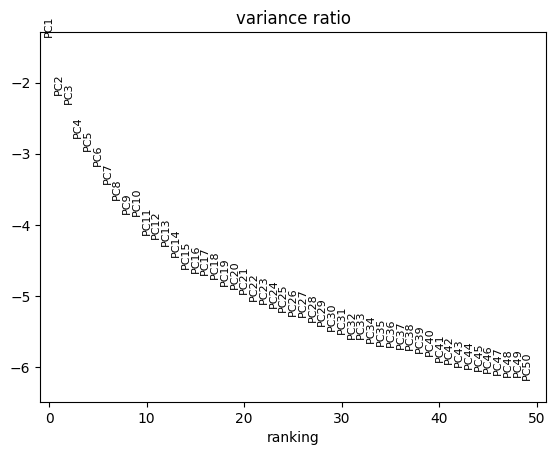

In [10]:
#Calculate PCs
sc.tl.pca(donor_adata)
sc.pl.pca_variance_ratio(donor_adata, n_pcs=50, log=True) #Plot PC variance ratios

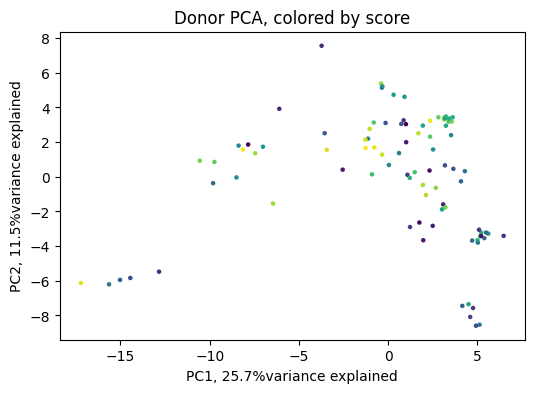

In [11]:
perc_var = donor_adata.uns['pca']['variance_ratio'] * 100
sc.tl.tsne(donor_adata, use_rep='X_pca', random_state=147)
df = pd.DataFrame({'PC1': donor_adata.obsm['X_pca'][:,0], 'PC2': donor_adata.obsm['X_pca'][:,1], 'score': donor_adata.obs['DEscore_long'].values})

plt.figure(figsize=(6,4))
plt.scatter(df['PC1'], df['PC2'], c=pd.Categorical(df['score']).codes, s=5, alpha=1)
plt.xlabel(f'PC1, {perc_var[0]:.1f}%variance explained')
plt.ylabel(f'PC2, {perc_var[1]:.1f}%variance explained')
plt.title('Donor PCA, colored by score')
plt.show()

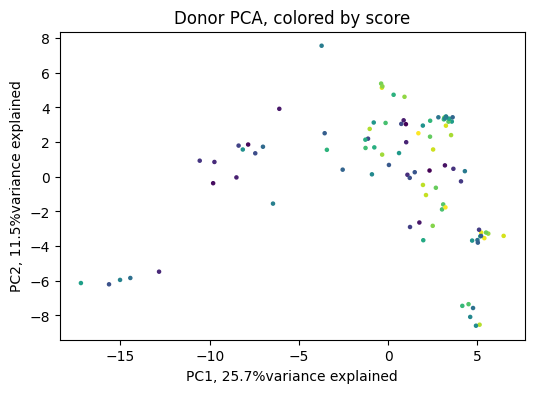

In [12]:
perc_var = donor_adata.uns['pca']['variance_ratio'] * 100
sc.tl.tsne(donor_adata, use_rep='X_pca', random_state=147)
df = pd.DataFrame({'PC1': donor_adata.obsm['X_pca'][:,0], 'PC2': donor_adata.obsm['X_pca'][:,1], 'pseudorank': donor_adata.obs['pseudorank'].values})

plt.figure(figsize=(6,4))
plt.scatter(df['PC1'], df['PC2'], c=pd.Categorical(df['pseudorank']).codes, s=5, alpha=1)
plt.xlabel(f'PC1, {perc_var[0]:.1f}%variance explained')
plt.ylabel(f'PC2, {perc_var[1]:.1f}%variance explained')
plt.title('Donor PCA, colored by score')
plt.show()

In [13]:
day0_pcs = pd.DataFrame(donor_adata.obsm['X_pca'], index=donor_adata.obs_names, columns=[f'PC{i+1}' for i in range(donor_adata.obsm['X_pca'].shape[1])])
day0_pcs.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
zapk,3.181929,0.660086,-1.156901,-1.338994,-0.100520,3.320299,1.582244,-0.981706,2.014731,-0.383449,...,0.617737,-0.222438,0.267443,0.314845,-0.733680,0.203613,-0.193274,-0.225907,0.142855,-0.694437
wibj,-2.547690,0.413058,-1.849295,1.165720,-2.684275,-0.665291,-0.199397,-0.281172,1.612072,-3.199867,...,-0.501535,0.391808,-0.144017,-0.242051,-0.109650,0.231788,-0.258578,-0.216250,0.406823,0.342120
pelm,2.320235,0.362718,-1.002284,-0.824520,0.575587,3.100321,0.103807,-0.789793,0.468751,0.908636,...,-0.038008,-0.498470,0.023480,0.185500,-0.152878,0.073034,0.017615,0.187021,0.061215,0.320523
vass,-0.807296,3.132881,-2.029991,-1.439614,-0.568322,-0.486264,-1.276130,-0.728340,-0.438251,-1.202127,...,-1.064911,0.521858,0.131770,1.100568,0.025072,-0.221206,0.244479,0.290150,0.021428,-0.045677
paab,1.491555,0.265067,2.365499,6.051101,-1.176274,1.801340,-0.853157,-1.687098,1.123861,2.129872,...,-0.714833,-0.330263,-0.688792,0.111910,0.157670,0.413958,-0.195304,-0.083680,0.197183,-0.876337


PCs don't seem to drastically correlate with DE score, based on looking at the color patterns.  Pseudotime score (aka pseudoranks) correlate with PCs a little better, but still not what we were hoping for.

Next, we will finding the genes that correlate with DE score (or psuedorank) the best. Hint: these are most likely not the most variable genes.

###Dimension Reduction: Correlating Genes

In [14]:
# Find genes that correlate with DE scores.
y = donor_adata.obs['DEscore_long'].values
corrs = []
for g in donor_adata.var_names:
  x = donor_adata[:, g].X.flatten()
  r, _ = spearmanr(x,y)
  corrs.append(r)
donor_adata.var['corr_DE'] = corrs

In [15]:
# Find genes that correlate with pseudoranks.
y = donor_adata.obs['pseudorank'].values
corrs = []
for g in donor_adata.var_names:
  x = donor_adata[:, g].X.flatten()
  r, _ = spearmanr(x,y)
  corrs.append(r)
donor_adata.var['corr_PR'] = corrs

In [16]:
#Sort donor_adata based on correlation to DE score, collect the 100 genes with the highest correlations
top_genes_score = donor_adata.var['corr_DE'].abs().sort_values(ascending=False).head(100).index

#Sort donor_adata based on correlation to pseudorank, collect the 100 genes with the highest correlations
top_genes_rank = donor_adata.var['corr_PR'].abs().sort_values(ascending=False).head(100).index

#Make new scanpy datasets with only the 100 selected genes correlating with DE_score and pseudorank, respectively
donor_score = donor_adata[:, top_genes_score].copy()
donor_rank = donor_adata[:, top_genes_rank].copy()

###Dimension Reduction: Gene Pathways

Here we will curated gene lists from the Broad Institute. These lists are part of the Human MSigDB Collections and are described in the following peer reviewed publication (see citation below).  Here, we are using 50 standard lists describing various normal and well described molecular pathways. Gene lists of this type are used to gleen information on the status and activity of the cells beyond their cellular identity.

Liberzon A, Birger C, Thorvaldsdóttir H, Ghandi M, Mesirov JP, Tamayo P. The Molecular Signatures Database (MSigDB) hallmark gene set collection. Cell Syst. 2015 Dec 23;1(6):417-425. doi: 10.1016/j.cels.2015.12.004. PMID: 26771021; PMCID: PMC4707969.

In [234]:
#file containing gene lists downloaded from GSEA website https://www.gsea-msigdb.org/gsea/msigdb/human/collections.jsp#H
import json
with open('/content/drive/MyDrive/Springboard/Capstone3_iPSC/h.all.v2026.1.Hs.txt', 'r') as file:
    data = json.load(file)

print(json.dumps(data, indent=4))

{
    "HALLMARK_TNFA_SIGNALING_VIA_NFKB": {
        "collection": "H",
        "systematicName": "M5890",
        "pmid": "26771021",
        "exactSource": "",
        "externalDetailsURL": "",
        "msigdbURL": "https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_TNFA_SIGNALING_VIA_NFKB",
        "geneSymbols": [
            "ABCA1",
            "ACKR3",
            "AREG",
            "ATF3",
            "ATP2B1",
            "B4GALT1",
            "B4GALT5",
            "BCL2A1",
            "BCL3",
            "BCL6",
            "BHLHE40",
            "BIRC2",
            "BIRC3",
            "BMP2",
            "BTG1",
            "BTG2",
            "BTG3",
            "CCL2",
            "CCL20",
            "CCL4",
            "CCL5",
            "CCN1",
            "CCND1",
            "CCNL1",
            "CCRL2",
            "CD44",
            "CD69",
            "CD80",
            "CD83",
            "CDKN1A",
            "CEBPB",
            "CEBPD",
    

In [235]:
#Converts the gene symbols we collected fromthe json to the gene name and ENSG code that is used in the column names of donor_adata
def build_marker_list(symbols, donor_adata):
  markers=[]
  for symbol in symbols:
    matches = [g for g in donor_adata.var_names if g.endswith(f"_{symbol}")]
    if len(matches) == 1:
      markers.append(matches[0])
    elif len(matches) > 1:
      print(f"Multiple matches for {symbol}: {matches}")
    else:
      print(f"No matches for {symbol}")
  return markers

In [236]:
pathways = pd.DataFrame(data)
pathway_dict = pathways.loc['geneSymbols'].to_dict()
gene_ids = {}
for key in pathway_dict:
  gene_ids[key] = build_marker_list(pathway_dict[key], donor_adata)

No matches for AREG
No matches for B4GALT5
No matches for BCL2A1
No matches for BCL3
No matches for BCL6
No matches for BIRC3
No matches for CCL20
No matches for CCL4
No matches for CCL5
No matches for CCN1
No matches for CCRL2
No matches for CD69
No matches for CD80
No matches for CEBPD
No matches for CLCF1
No matches for CSF1
No matches for CSF2
No matches for CXCL1
No matches for CXCL10
No matches for CXCL11
No matches for CXCL2
No matches for EDN1
No matches for EGR2
No matches for EGR3
No matches for FOSB
No matches for FOSL2
No matches for FUT4
No matches for G0S2
No matches for GEM
No matches for GPR183
No matches for HBEGF
No matches for ICAM1
No matches for ICOSLG
No matches for IFIH1
No matches for IFIT2
No matches for IL12B
No matches for IL15RA
No matches for IL18
No matches for IL1A
No matches for IL1B
No matches for IL6
No matches for IL7R
No matches for INHBA
No matches for IRS2
No matches for JAG1
No matches for KLF2
No matches for KLF4
No matches for KLF9
No matches fo

In [237]:
#Calculate score for each pathway for each donor
for key in gene_ids:
  sc.tl.score_genes(donor_adata, gene_list=gene_ids[key], score_name=key)
donor_adata.obs.columns

Index(['DEscore_long', 'DEscore_short', 'pseudorank',
       'HALLMARK_TNFA_SIGNALING_VIA_NFKB', 'HALLMARK_HYPOXIA',
       'HALLMARK_CHOLESTEROL_HOMEOSTASIS', 'HALLMARK_MITOTIC_SPINDLE',
       'HALLMARK_WNT_BETA_CATENIN_SIGNALING', 'HALLMARK_TGF_BETA_SIGNALING',
       'HALLMARK_IL6_JAK_STAT3_SIGNALING', 'HALLMARK_DNA_REPAIR',
       'HALLMARK_G2M_CHECKPOINT', 'HALLMARK_APOPTOSIS',
       'HALLMARK_NOTCH_SIGNALING', 'HALLMARK_ADIPOGENESIS',
       'HALLMARK_ESTROGEN_RESPONSE_EARLY', 'HALLMARK_ESTROGEN_RESPONSE_LATE',
       'HALLMARK_ANDROGEN_RESPONSE', 'HALLMARK_MYOGENESIS',
       'HALLMARK_PROTEIN_SECRETION', 'HALLMARK_INTERFERON_ALPHA_RESPONSE',
       'HALLMARK_INTERFERON_GAMMA_RESPONSE', 'HALLMARK_APICAL_JUNCTION',
       'HALLMARK_APICAL_SURFACE', 'HALLMARK_HEDGEHOG_SIGNALING',
       'HALLMARK_COMPLEMENT', 'HALLMARK_UNFOLDED_PROTEIN_RESPONSE',
       'HALLMARK_PI3K_AKT_MTOR_SIGNALING', 'HALLMARK_MTORC1_SIGNALING',
       'HALLMARK_E2F_TARGETS', 'HALLMARK_MYC_TARGETS_V1',
    

In [238]:
# Find pathway scores that correlate with DE scores.
y = donor_adata.obs['DEscore_long'].values
corrs = {}
for pathway in gene_ids.keys():
  x = donor_adata.obs[pathway].values
  r, _ = spearmanr(x,y)
  corrs[pathway] = r
corr_df_score = pd.DataFrame.from_dict(corrs, orient='index', columns=['corr_DE'])
corr_df_score.sort_values(by='corr_DE', ascending=False)

,corr_DE
HALLMARK_MYC_TARGETS_V2,0.539417
HALLMARK_DNA_REPAIR,0.375984
HALLMARK_E2F_TARGETS,0.352804
HALLMARK_MYC_TARGETS_V1,0.333154
HALLMARK_G2M_CHECKPOINT,0.327559
HALLMARK_UNFOLDED_PROTEIN_RESPONSE,0.262642
HALLMARK_PANCREAS_BETA_CELLS,0.240772
HALLMARK_UV_RESPONSE_UP,0.230106
HALLMARK_MTORC1_SIGNALING,0.223109
HALLMARK_PI3K_AKT_MTOR_SIGNALING,0.180432


In [239]:
# Find pathway scores that correlate with pseudoranks.
y = donor_adata.obs['pseudorank'].values
corrs = {}
for pathway in gene_ids.keys():
  x = donor_adata.obs[pathway].values
  r, _ = spearmanr(x,y)
  corrs[pathway] = r
corr_df_rank = pd.DataFrame.from_dict(corrs, orient='index', columns=['corr_PR'])
corr_df_rank.sort_values(by='corr_PR', ascending=False)

,corr_PR
HALLMARK_MYC_TARGETS_V2,0.326526
HALLMARK_DNA_REPAIR,0.314874
HALLMARK_PANCREAS_BETA_CELLS,0.213924
HALLMARK_MYC_TARGETS_V1,0.166977
HALLMARK_E2F_TARGETS,0.161691
HALLMARK_G2M_CHECKPOINT,0.148421
HALLMARK_MTORC1_SIGNALING,0.096512
HALLMARK_CHOLESTEROL_HOMEOSTASIS,0.081038
HALLMARK_BILE_ACID_METABOLISM,0.027511
HALLMARK_OXIDATIVE_PHOSPHORYLATION,0.003992


In [240]:
#Find 20 pathways with the greatest absolute correlation with DE score
corr_df = corr_df_score.merge(corr_df_rank, how='inner', right_index=True, left_index=True)
top_pathways = corr_df['corr_DE'].abs().sort_values(ascending=False).head(20).index
top_pathways

Index(['HALLMARK_MYC_TARGETS_V2', 'HALLMARK_ANGIOGENESIS',
       'HALLMARK_UV_RESPONSE_DN', 'HALLMARK_KRAS_SIGNALING_UP',
       'HALLMARK_P53_PATHWAY', 'HALLMARK_TNFA_SIGNALING_VIA_NFKB',
       'HALLMARK_DNA_REPAIR', 'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION',
       'HALLMARK_INTERFERON_ALPHA_RESPONSE', 'HALLMARK_HEME_METABOLISM',
       'HALLMARK_E2F_TARGETS', 'HALLMARK_IL2_STAT5_SIGNALING',
       'HALLMARK_INTERFERON_GAMMA_RESPONSE', 'HALLMARK_NOTCH_SIGNALING',
       'HALLMARK_MYC_TARGETS_V1', 'HALLMARK_G2M_CHECKPOINT',
       'HALLMARK_COAGULATION', 'HALLMARK_HYPOXIA', 'HALLMARK_APICAL_JUNCTION',
       'HALLMARK_INFLAMMATORY_RESPONSE'],
      dtype='object')

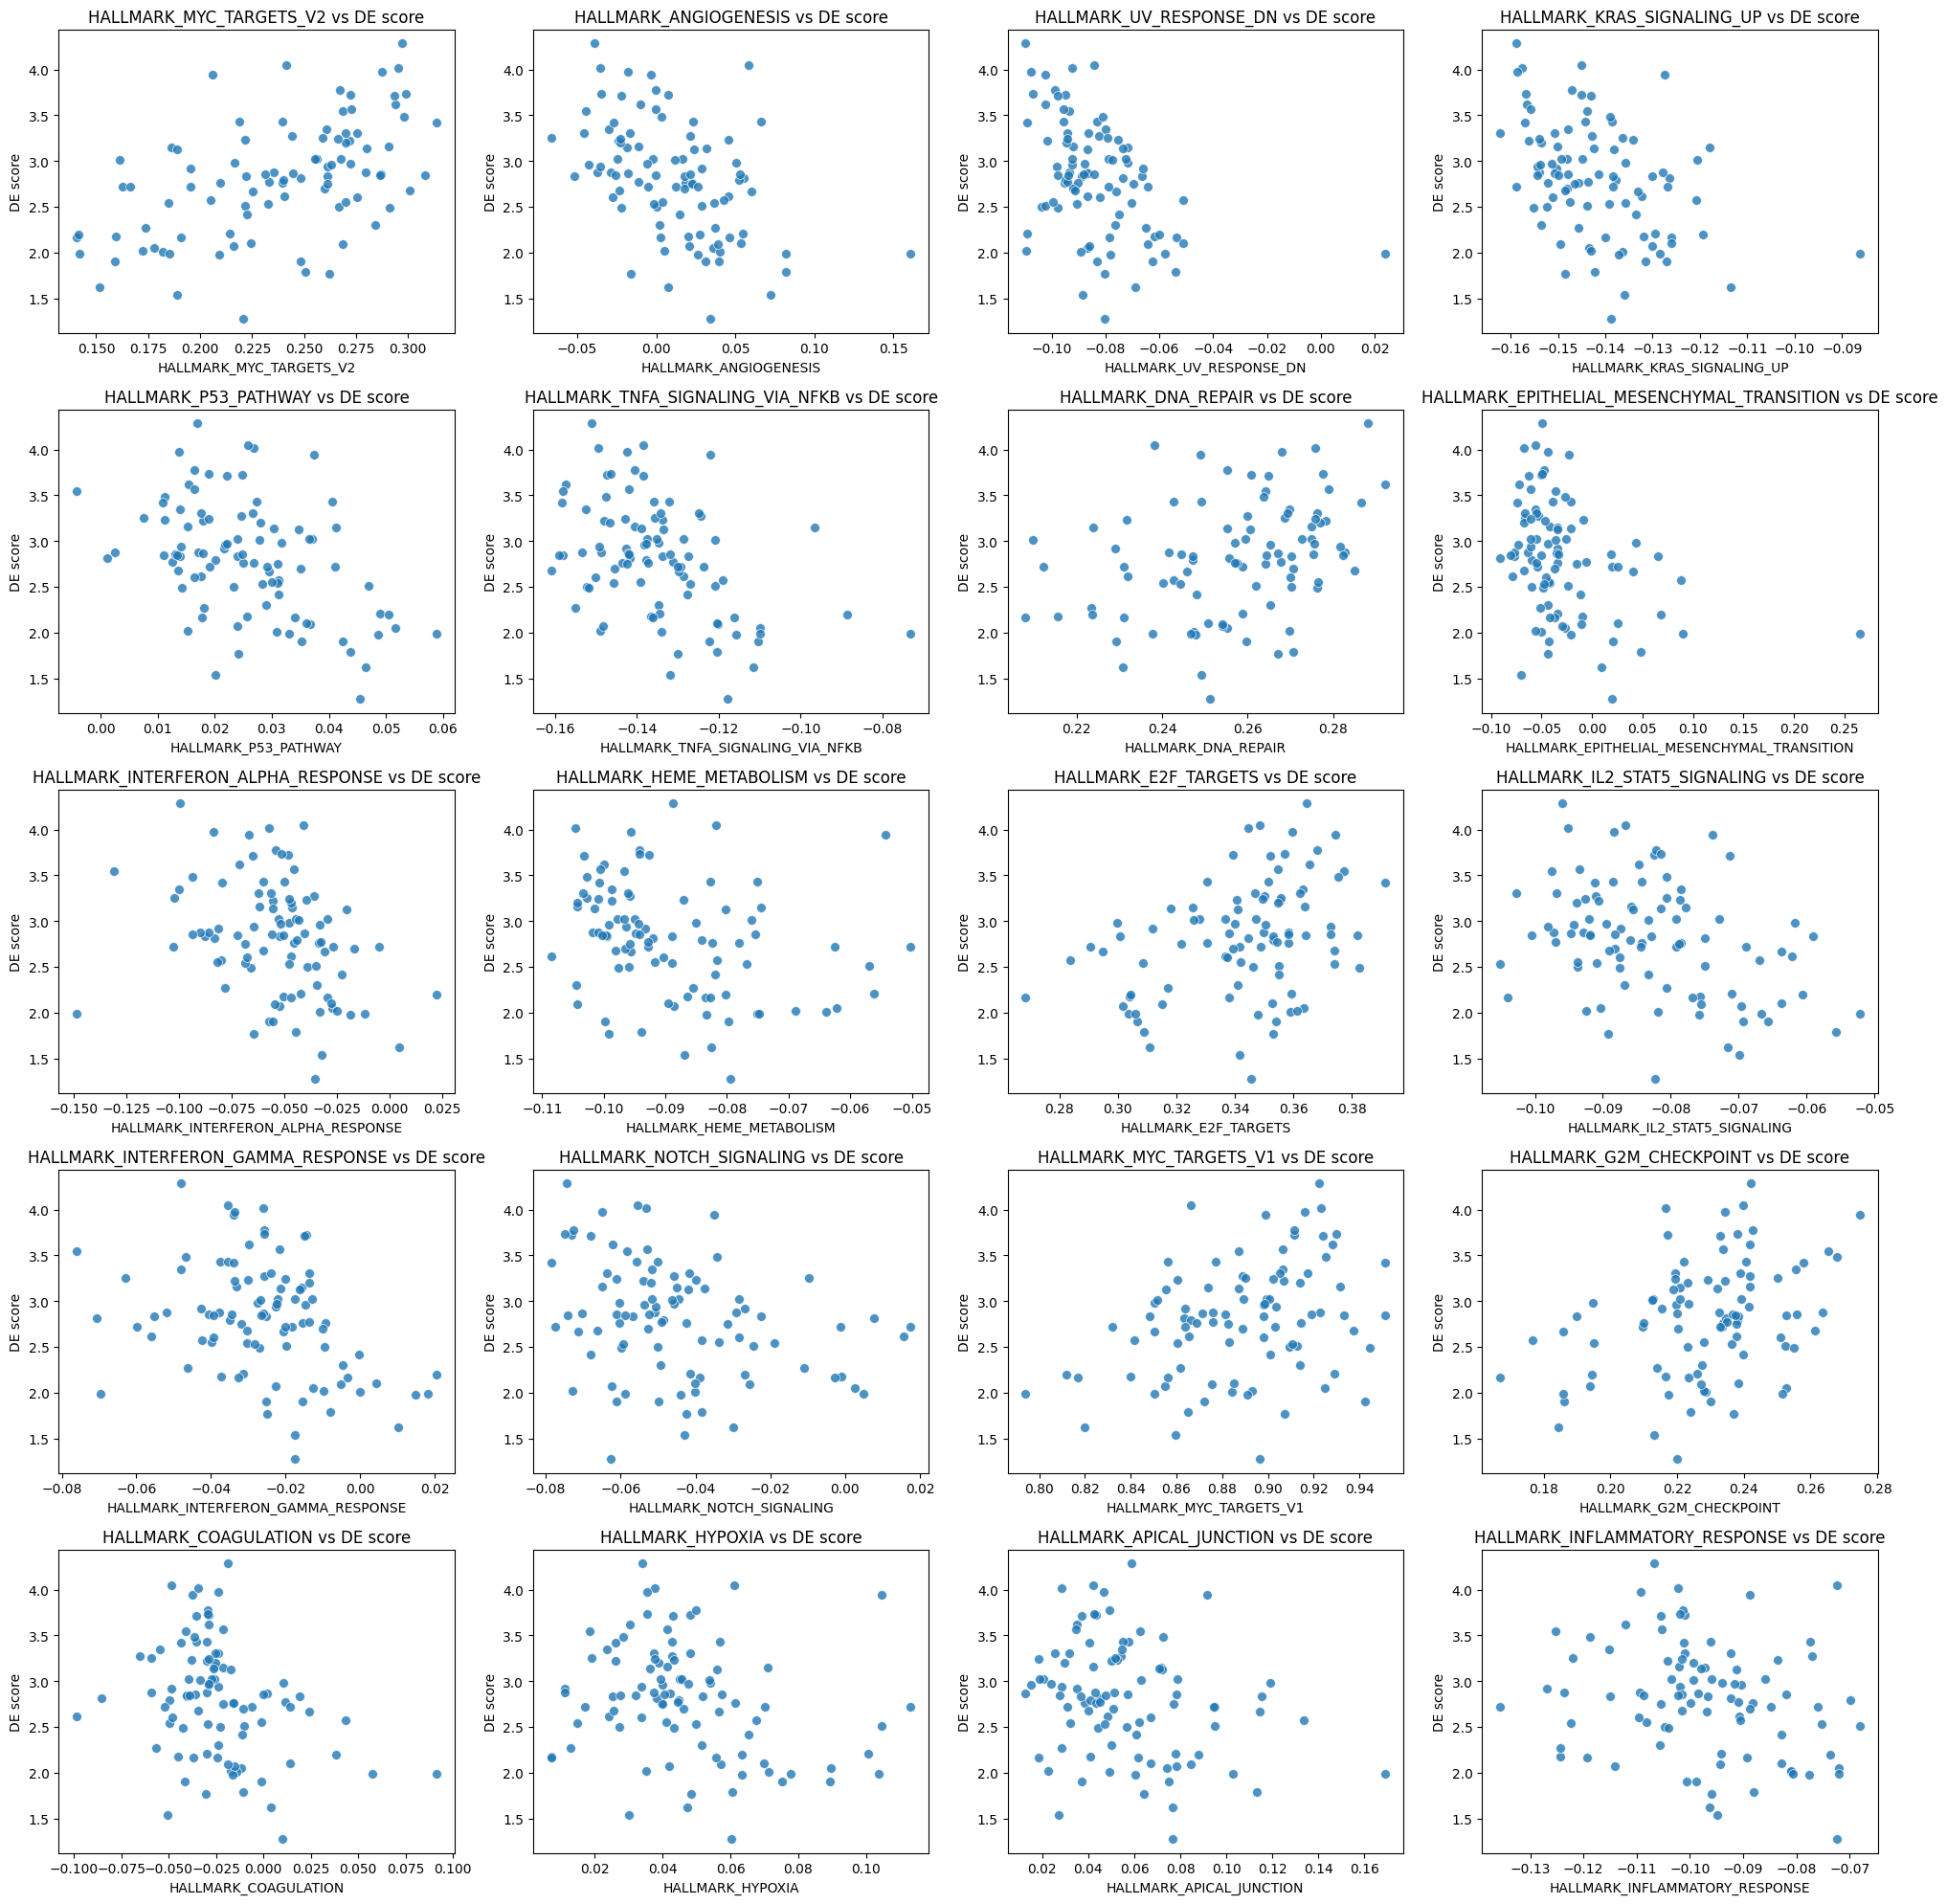

In [241]:
fig, ax = plt.subplots(5, 4, figsize=(20,20))
ax = ax.flatten()
for i, pathway in enumerate(top_pathways):
  sns.scatterplot(x=donor_adata.obs[pathway], y=donor_adata.obs['DEscore_long'], ax=ax[i], s=50, alpha=0.8)
  ax[i].set_title(f'{pathway} vs DE score')
  ax[i].set_xlabel(pathway)
  ax[i].set_ylabel('DE score')
plt.tight_layout()
plt.show()

We now have three types of features describing the psuedobulk donor counts that we can use to build a data set that can be modelled:

1) **PCs from PCA on top 500 HVGs.**  
Pros: Unbiased, visually correlates a bit with pseudorank  
Cons: Unintuitive and doesn't correlate very well with DE score.

2) **Genes with highest absolute value correlations with DE score/pseudorank**  
Pros: More intuitive, and the only features that don't require RNA-seq to reproduce for subsequent datasets.  
Cons: None of the genes had a correlation greater that R2=6%, so modelling might not work.

3) **Scores based on 50 gene lists describing known genetic pathways.**  
Pros: Very intuitive, since the pathways with the largest and smallest R2 values make biological sense.  Using pathways is also more robust than individual genes since groups of genes are less sensitive to noise and batch vairiation.  Also, the pathways have high enough correlation with DE score and pseudorank that modelling will likely be successful.  
Cons: Analysis is the most complicated and requires full RNAseq to test for the gene lists.

##Model Building: Screening Learners

I will test two data set for modelling with regressors, using a tree based approach.

**First**, we will try using the 100 individual genes with the greatest correlations with DE score, as this model would remove the necessity of RNAseq to produce future datasets. These datasets are already saved as `donor_score` and `donor_rank`, respectively.

**Second**, we will build a data set with any pathway with a correleation absolute value of 10 or more (10 is an arbitrary threshold) plus the PC1 through PC10.  We can narrow the features down as we go based on feature importance. These we will save as `pathways_score` and `pathways_rank`, respectively.

In [159]:
#make list of pathways with correlation of +/- 10% with DE Score and pseudorank.  Compare lists.
selected_pathways_score = corr_df_score.index[abs(corr_df_score['corr_DE']) >= 0.10]
selected_pathways_rank = corr_df_rank.index[abs(corr_df_rank['corr_PR']) >= 0.10]
print(len(selected_pathways_score), len(selected_pathways_rank)) #Get number of pathways in each list
sorted(selected_pathways_score) == sorted(selected_pathways_rank) #Compare lists

40 41


False

Since both lists are the same, we do not need separate dfs for `pathways_score` and `pathways_rank` and can use one dataset, `donor_pathways`.

In [242]:
#Merge selected pathways with PCs 1-10 for DE score data set
cols = ['DEscore_long', 'DEscore_short', 'pseudorank'] + list(selected_pathways_score)
donor_pathways = pd.DataFrame(donor_adata.obs[cols])
donor_pathways = donor_pathways.merge(day0_pcs.iloc[:, 0:10], left_index=True, right_index=True, how='inner')
donor_pathways.head()

,DEscore_long,DEscore_short,pseudorank,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_HYPOXIA,HALLMARK_MITOTIC_SPINDLE,HALLMARK_IL6_JAK_STAT3_SIGNALING,HALLMARK_DNA_REPAIR,HALLMARK_G2M_CHECKPOINT,HALLMARK_APOPTOSIS,...,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
zapk,2.296221,5.776403,0.719840,-0.134793,0.051612,-0.090113,-0.053509,0.265365,0.227457,0.038244,...,3.181929,0.660086,-1.156901,-1.338994,-0.100520,3.320299,1.582244,-0.981706,2.014731,-0.383449
wibj,1.908312,5.802939,0.763244,-0.110360,0.075257,-0.083210,-0.059183,0.259668,0.230118,0.028932,...,-2.547690,0.413058,-1.849295,1.165720,-2.684275,-0.665291,-0.199397,-0.281172,1.612072,-3.199867
pelm,1.768026,5.667831,0.690719,-0.130050,0.048310,-0.083136,-0.053200,0.267120,0.237066,0.035298,...,2.320235,0.362718,-1.002284,-0.824520,0.575587,3.100321,0.103807,-0.789793,0.468751,0.908636
vass,3.160267,8.296805,0.782916,-0.140513,0.041330,-0.087477,-0.068831,0.274806,0.241718,0.041418,...,-0.807296,3.132881,-2.029991,-1.439614,-0.568322,-0.486264,-1.276130,-0.728340,-0.438251,-1.202127
paab,3.145534,10.150320,0.759001,-0.096603,0.070862,-0.057886,-0.048852,0.223829,0.220850,0.053053,...,1.491555,0.265067,2.365499,6.051101,-1.176274,1.801340,-0.853157,-1.687098,1.123861,2.129872


In [243]:
donor_pathways.shape

(92, 53)

Now we can proceed with train, test splits on our final datasets.

Model screening will start with DE score and then we'll test the best learners with pseudorank predictions.

In [248]:
def normalize_log(df):
    arr = df.values
    counts = arr / arr.sum(axis=1, keepdims=True) * 1e4
    zero_rows = df[df.sum(axis=1) == 0]
    return pd.DataFrame(np.log1p(counts), index=df.index, columns=df.columns)

In [245]:
donor_score.layers['counts'].max()

np.float64(3595567.469542)

In [249]:
#For correlating genes, predicting DE score
donor_score.X = donor_score.layers['counts']
X = pd.DataFrame(donor_score.X, columns=donor_score.var_names, index=donor_score.obs_names)
y = donor_score.obs['DEscore_long']

X_train_score, X_test_score, y_train_score, y_test_score = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_score = normalize_log(X_train_score)
X_test_score = normalize_log(X_test_score)

In [250]:
#For correlating genes, predicting pseudorank
donor_rank.X = donor_rank.layers['counts']
X = pd.DataFrame(donor_rank.X, columns=donor_rank.var_names, index=donor_rank.obs_names)
y = donor_rank.obs['pseudorank']

X_train_rank, X_test_rank, y_train_rank, y_test_rank = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_rank = normalize_log(X_train_rank)
X_test_rank = normalize_log(X_test_rank)

### Using Correlating Genes

####Predicting DE Score

In [251]:
#Run default linear regression on dataset
LR = LinearRegression()
LR.fit(X_train_score, y_train_score)
LR.score(X_train_score, y_train_score)

1.0

In [252]:
#Determine MAE with test data
y_pred_LR = np.array(LR.predict(X_test_score))
mae_LR = mean_absolute_error(y_test_score, y_pred_LR)
mape_LR = mean_absolute_percentage_error(y_test_score, y_pred_LR)
print(f'Linear Regression MAE: {mae_LR}')

Linear Regression MAE: 0.5686019551370249


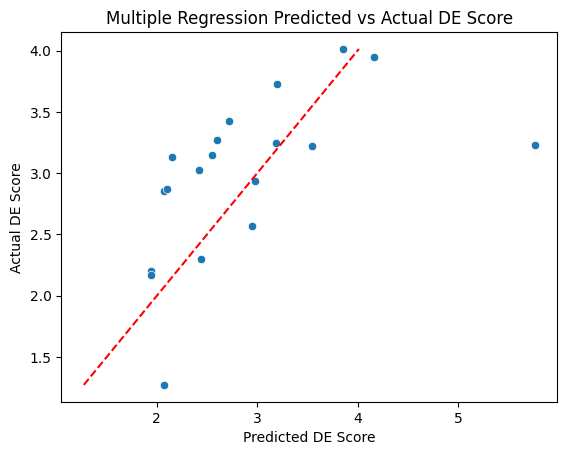

In [253]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_LR, y=y_test_score)

# Add a line for perfect correlation.
plt.plot([y_test_score.min(), y_test_score.max()],
         [y_test_score.min(), y_test_score.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Multiple Regression Predicted vs Actual DE Score')
plt.show()

In [254]:
#Run default Random Forest regression on dataset
RF = RandomForestRegressor()
RF.fit(X_train_score, y_train_score)
RF.score(X_train_score, y_train_score)

0.9238963367242721

In [255]:
#Determine MAE with test data
y_pred_RF = np.array(RF.predict(X_test_score))
y_pred_RF_score_genes = np.array(RF.predict(X_test_score))
mae_RF = mean_absolute_error(y_test_score, y_pred_RF)
mape_RF = mean_absolute_percentage_error(y_test_score, y_pred_RF)
print(f'Random Forest Regression MAE: {mae_RF}')

Random Forest Regression MAE: 0.40480497530571924


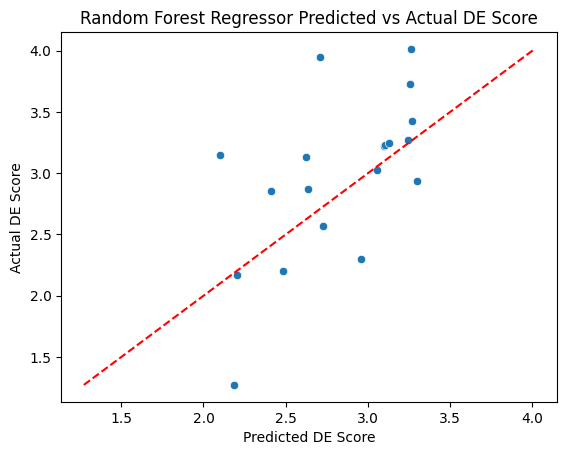

In [256]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_RF, y=y_test_score)

# Add a line for perfect correlation.
plt.plot([y_test_score.min(), y_test_score.max()],
         [y_test_score.min(), y_test_score.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Random Forest Regressor Predicted vs Actual DE Score')
plt.show()

In [257]:
#Run default Grandient Boosting regression on dataset
GB = GradientBoostingRegressor()
GB.fit(X_train_score, y_train_score)
GB.score(X_train_score, y_train_score)

0.9998104749486336

In [258]:
#Determine MAE with test data
y_pred_GB = np.array(GB.predict(X_test_score))
mae_GB = mean_absolute_error(y_test_score, y_pred_GB)
mape_GB = mean_absolute_percentage_error(y_test_score, y_pred_GB)
print(f'Grandient Boosting Regression MAE: {mae_GB}')

Grandient Boosting Regression MAE: 0.4012360010684539


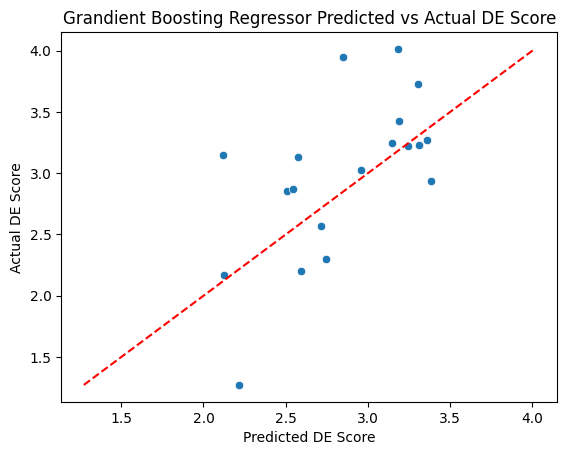

In [259]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_GB, y=y_test_score)

# Add a line for perfect correlation.
plt.plot([y_test_score.min(), y_test_score.max()],
         [y_test_score.min(), y_test_score.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Grandient Boosting Regressor Predicted vs Actual DE Score')
plt.show()

In [260]:
#Run default XGBoost regression on dataset
XG = XGBRegressor()
XG.fit(X_train_score, y_train_score)
XG.score(X_train_score, y_train_score)

0.9999995487400316

In [261]:
#Determine MAE with test data
y_pred_XG = np.array(XG.predict(X_test_score))
mae_XG = mean_absolute_error(y_test_score, y_pred_XG)
mape_XG = mean_absolute_percentage_error(y_test_score, y_pred_XG)
print(f'XGBoost Regression MAE: {mae_XG}')

XGBoost Regression MAE: 0.45687917707028447


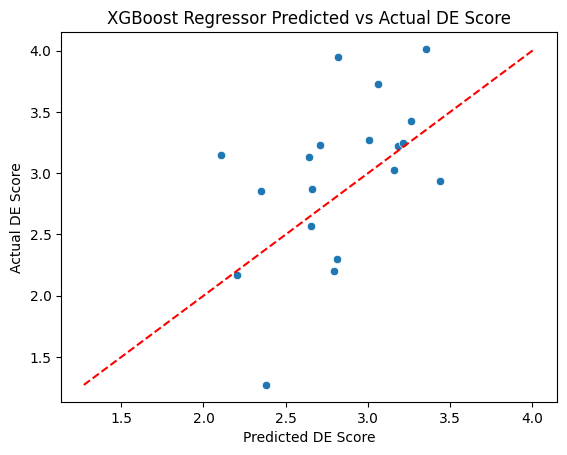

In [262]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_XG, y=y_test_score)

# Add a line for perfect correlation.
plt.plot([y_test_score.min(), y_test_score.max()],
         [y_test_score.min(), y_test_score.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('XGBoost Regressor Predicted vs Actual DE Score')
plt.show()

In [263]:
#Run default CatBoost regression on dataset
CB = CatBoostRegressor()
CB.fit(X_train_score, y_train_score)
CB.score(X_train_score, y_train_score)

Learning rate set to 0.027076
0:	learn: 0.5984708	total: 3.31ms	remaining: 3.3s
1:	learn: 0.5928706	total: 5.89ms	remaining: 2.94s
2:	learn: 0.5867061	total: 10.1ms	remaining: 3.37s
3:	learn: 0.5806490	total: 14.2ms	remaining: 3.53s
4:	learn: 0.5750948	total: 17.2ms	remaining: 3.42s
5:	learn: 0.5694375	total: 19.7ms	remaining: 3.26s
6:	learn: 0.5633121	total: 22.1ms	remaining: 3.14s
7:	learn: 0.5568677	total: 24.6ms	remaining: 3.05s
8:	learn: 0.5516420	total: 29ms	remaining: 3.2s
9:	learn: 0.5475357	total: 34ms	remaining: 3.37s
10:	learn: 0.5414470	total: 36.7ms	remaining: 3.3s
11:	learn: 0.5354946	total: 39.4ms	remaining: 3.24s
12:	learn: 0.5299417	total: 42.2ms	remaining: 3.2s
13:	learn: 0.5243809	total: 46ms	remaining: 3.24s
14:	learn: 0.5190025	total: 49.6ms	remaining: 3.25s
15:	learn: 0.5140561	total: 53.1ms	remaining: 3.27s
16:	learn: 0.5086133	total: 56.2ms	remaining: 3.25s
17:	learn: 0.5043724	total: 58.7ms	remaining: 3.2s
18:	learn: 0.4999926	total: 61.5ms	remaining: 3.17s
19:

np.float64(0.9999985119212258)

In [264]:
#Determine MAE with test data
y_pred_CB = np.array(CB.predict(X_test_score))
y_pred_CB_score_genes = np.array(CB.predict(X_test_score))
mae_CB = mean_absolute_error(y_test_score, y_pred_CB)
mape_CB = mean_absolute_percentage_error(y_test_score, y_pred_CB)
print(f'Grandient Boosting Regression MAE: {mae_CB}')

Grandient Boosting Regression MAE: 0.4100108137393179


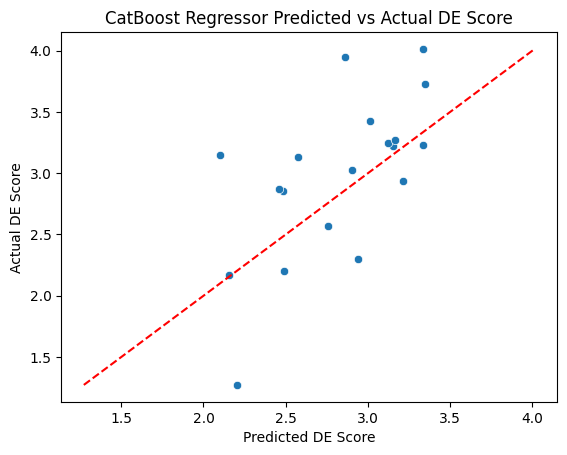

In [265]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_CB, y=y_test_score)

# Add a line for perfect correlation.
plt.plot([y_test_score.min(), y_test_score.max()],
         [y_test_score.min(), y_test_score.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('CatBoost Regressor Predicted vs Actual DE Score')
plt.show()

In [266]:
MAE_dict = {'Multiple Linear Regression': mae_LR, 'Random Forest Regressor': mae_RF, 'Gradient Boost Regressor': mae_GB, 'XGBoost Regressor': mae_XG, 'CatBoost Regressor': mae_CB}
MAPE_dict = {'Multiple Linear Regression': mape_LR, 'Random Forest Regressor': mape_RF, 'Gradient Boost Regressor': mape_GB, 'XGBoost Regressor': mape_XG, 'CatBoost Regressor': mape_CB}
Rsquared_dict = {'Multiple Linear Regression': LR.score(X_train_score, y_train_score), 'Random Forest Regressor': RF.score(X_train_score, y_train_score), 'Gradient Boost Regressor': GB.score(X_train_score, y_train_score),
                 'XGBoost Regressor': XG.score(X_train_score, y_train_score), 'CatBoost Regressor': CB.score(X_train_score, y_train_score)}
summary_genes_score = pd.DataFrame({'MAE': MAE_dict, 'MAPE': MAPE_dict, 'R²': Rsquared_dict})
summary_genes_score

,MAE,MAPE,R²
Multiple Linear Regression,0.568602,0.204038,1.000000
Random Forest Regressor,0.404805,0.151211,0.923896
Gradient Boost Regressor,0.401236,0.150670,0.999810
XGBoost Regressor,0.456879,0.173794,1.000000
CatBoost Regressor,0.410011,0.153956,0.999999


####Predicting Pseudorank

In [267]:
#Run default linear regression on dataset
LR = LinearRegression()
LR.fit(X_train_rank, y_train_rank)
LR.score(X_train_rank, y_train_rank)

1.0

In [268]:
#Determine MAE with test data
y_pred_LR = np.array(LR.predict(X_test_rank))
mae_LR = mean_absolute_error(y_test_rank, y_pred_LR)
mape_LR = mean_absolute_percentage_error(y_test_rank, y_pred_LR)
print(f'Linear Regression MAE: {mae_LR}')

Linear Regression MAE: 0.04734697500009018


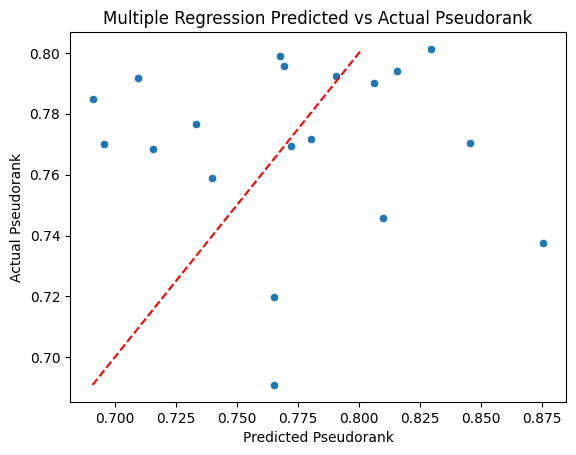

In [269]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_LR, y=y_test_rank)

# Add a line for perfect correlation.
plt.plot([y_test_rank.min(), y_test_rank.max()],
         [y_test_rank.min(), y_test_rank.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Multiple Regression Predicted vs Actual Pseudorank')
plt.show()

In [270]:
#Run default Random Forest regression on dataset
RF = RandomForestRegressor()
RF.fit(X_train_rank, y_train_rank)
RF.score(X_train_rank, y_train_rank)

0.9153134588075449

In [271]:
#Determine MAE with test data
y_pred_RF = np.array(RF.predict(X_test_rank))
y_pred_RF_rank_genes = np.array(RF.predict(X_test_rank))
mae_RF = mean_absolute_error(y_test_rank, y_pred_RF)
mape_RF = mean_absolute_percentage_error(y_test_rank, y_pred_RF)
print(f'Random Forest Regression MAE: {mae_RF}')

Random Forest Regression MAE: 0.016203842068973347


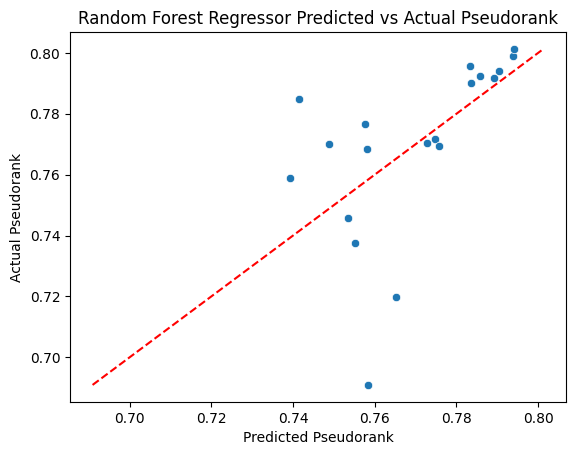

In [272]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_RF, y=y_test_rank)

# Add a line for perfect correlation.
plt.plot([y_test_rank.min(), y_test_rank.max()],
         [y_test_rank.min(), y_test_rank.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Random Forest Regressor Predicted vs Actual Pseudorank')
plt.show()

In [273]:
#Run default Grandient Boosting regression on dataset
GB = GradientBoostingRegressor()
GB.fit(X_train_rank, y_train_rank)
GB.score(X_train_rank, y_train_rank)

0.9999015030196474

In [274]:
#Determine MAE with test data
y_pred_GB = np.array(GB.predict(X_test_rank))
mae_GB = mean_absolute_error(y_test_rank, y_pred_GB)
mape_GB = mean_absolute_percentage_error(y_test_rank, y_pred_GB)
print(f'Grandient Boosting Regression MAE: {mae_GB}')

Grandient Boosting Regression MAE: 0.015705904276657436


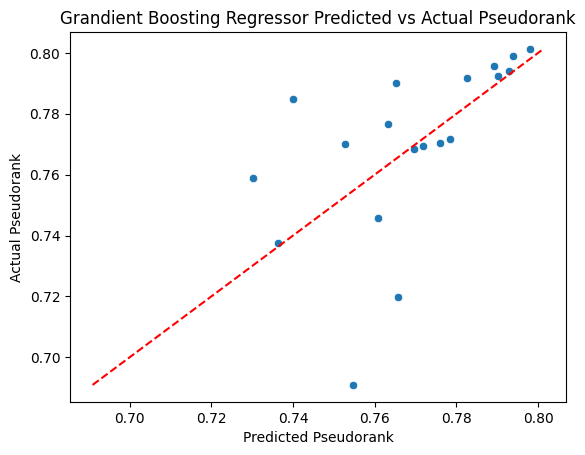

In [275]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_GB, y=y_test_rank)

# Add a line for perfect correlation.
plt.plot([y_test_rank.min(), y_test_rank.max()],
         [y_test_rank.min(), y_test_rank.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Grandient Boosting Regressor Predicted vs Actual Pseudorank')
plt.show()

In [276]:
#Run default XGBoost regression on dataset
XG = XGBRegressor()
XG.fit(X_train_rank, y_train_rank)
XG.score(X_train_rank, y_train_rank)

0.9997801780700684

In [277]:
#Determine MAE with test data
y_pred_XG = np.array(XG.predict(X_test_rank))
mae_XG = mean_absolute_error(y_test_rank, y_pred_XG)
mape_XG = mean_absolute_percentage_error(y_test_rank, y_pred_XG)
print(f'XGBoost Regression MAE: {mae_XG}')

XGBoost Regression MAE: 0.01685868762433529


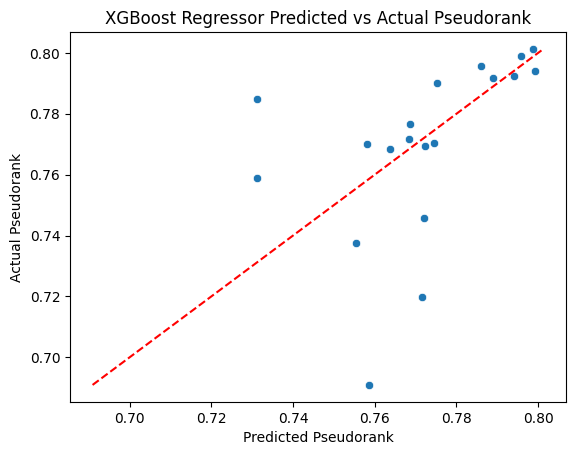

In [278]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_XG, y=y_test_rank)

# Add a line for perfect correlation.
plt.plot([y_test_rank.min(), y_test_rank.max()],
         [y_test_rank.min(), y_test_rank.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('XGBoost Regressor Predicted vs Actual Pseudorank')
plt.show()

In [279]:
#Run default CatBoost regression on dataset
CB = CatBoostRegressor()
CB.fit(X_train_rank, y_train_rank)
CB.score(X_train_rank, y_train_rank)

Learning rate set to 0.027076
0:	learn: 0.0246489	total: 3.66ms	remaining: 3.66s
1:	learn: 0.0243869	total: 6.56ms	remaining: 3.27s
2:	learn: 0.0241063	total: 9.66ms	remaining: 3.21s
3:	learn: 0.0238328	total: 12.6ms	remaining: 3.14s
4:	learn: 0.0235860	total: 16.1ms	remaining: 3.2s
5:	learn: 0.0233472	total: 19.4ms	remaining: 3.21s
6:	learn: 0.0231121	total: 22ms	remaining: 3.11s
7:	learn: 0.0228588	total: 24.6ms	remaining: 3.06s
8:	learn: 0.0226409	total: 27.2ms	remaining: 3s
9:	learn: 0.0224257	total: 30ms	remaining: 2.97s
10:	learn: 0.0222464	total: 32.9ms	remaining: 2.96s
11:	learn: 0.0220215	total: 35.8ms	remaining: 2.94s
12:	learn: 0.0218468	total: 38.5ms	remaining: 2.92s
13:	learn: 0.0216180	total: 41.3ms	remaining: 2.91s
14:	learn: 0.0213930	total: 43.9ms	remaining: 2.88s
15:	learn: 0.0211503	total: 46.5ms	remaining: 2.86s
16:	learn: 0.0209749	total: 49.2ms	remaining: 2.84s
17:	learn: 0.0207750	total: 51.9ms	remaining: 2.83s
18:	learn: 0.0205620	total: 54.7ms	remaining: 2.83s


np.float64(0.9999989590169746)

In [280]:
#Determine MAE with test data
y_pred_CB = np.array(CB.predict(X_test_rank))
y_pred_CB_rank_genes = np.array(CB.predict(X_test_rank))
mae_CB = mean_absolute_error(y_test_rank, y_pred_CB)
mape_CB = mean_absolute_percentage_error(y_test_rank, y_pred_CB)
print(f'Grandient Boosting Regression MAE: {mae_CB}')

Grandient Boosting Regression MAE: 0.015048846789612469


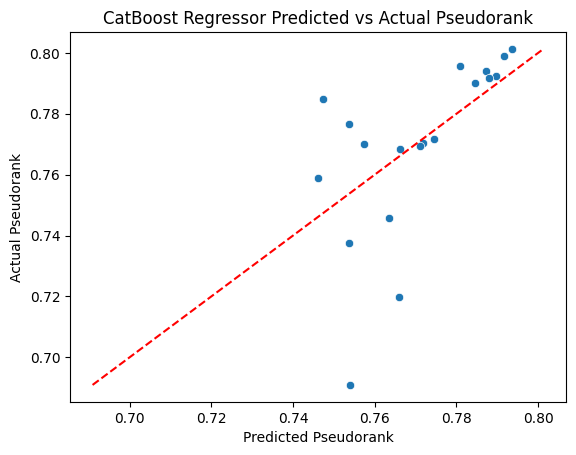

In [281]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_CB, y=y_test_rank)

# Add a line for perfect correlation.
plt.plot([y_test_rank.min(), y_test_rank.max()],
         [y_test_rank.min(), y_test_rank.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('CatBoost Regressor Predicted vs Actual Pseudorank')
plt.show()

In [282]:
MAE_dict = {'Multiple Linear Regression': mae_LR, 'Random Forest Regressor': mae_RF, 'Gradient Boost Regressor': mae_GB, 'XGBoost Regressor': mae_XG, 'CatBoost Regressor': mae_CB}
MAPE_dict = {'Multiple Linear Regression': mape_LR, 'Random Forest Regressor': mape_RF, 'Gradient Boost Regressor': mape_GB, 'XGBoost Regressor': mape_XG, 'CatBoost Regressor': mape_CB}
Rsquared_dict = {'Multiple Linear Regression': LR.score(X_train_rank, y_train_rank), 'Random Forest Regressor': RF.score(X_train_rank, y_train_rank), 'Gradient Boost Regressor': GB.score(X_train_rank, y_train_rank),
                 'XGBoost Regressor': XG.score(X_train_rank, y_train_rank), 'CatBoost Regressor': CB.score(X_train_rank, y_train_rank)}
summary_genes_rank = pd.DataFrame({'MAE': MAE_dict, 'MAPE': MAPE_dict, 'R²': Rsquared_dict})
summary_genes_rank

,MAE,MAPE,R²
Multiple Linear Regression,0.047347,0.062277,1.000000
Random Forest Regressor,0.016204,0.021715,0.915313
Gradient Boost Regressor,0.015706,0.021009,0.999902
XGBoost Regressor,0.016859,0.022656,0.999780
CatBoost Regressor,0.015049,0.020189,0.999999


###Using Correlating Pathways

####Predicting DE Score

In [283]:
X = donor_pathways.drop(columns=['DEscore_long', 'DEscore_short', 'pseudorank'])
y = donor_pathways['DEscore_long']

X_train_path, X_test_path, y_train_path, y_test_path = train_test_split(X, y, test_size=0.2, random_state=12)

In [284]:
#Run default linear regression on dataset
LR = LinearRegression()
LR.fit(X_train_path, y_train_path)
LR.score(X_train_path, y_train_path)

0.9262341153518265

In [285]:
#Determine MAE with test data
y_pred_LR = np.array(LR.predict(X_test_path))
mae_LR = mean_absolute_error(y_test_path, y_pred_LR)
mape_LR = mean_absolute_percentage_error(y_test_path, y_pred_LR)
print(f'Linear Regression MAE: {mae_LR}')

Linear Regression MAE: 0.6309353836827138


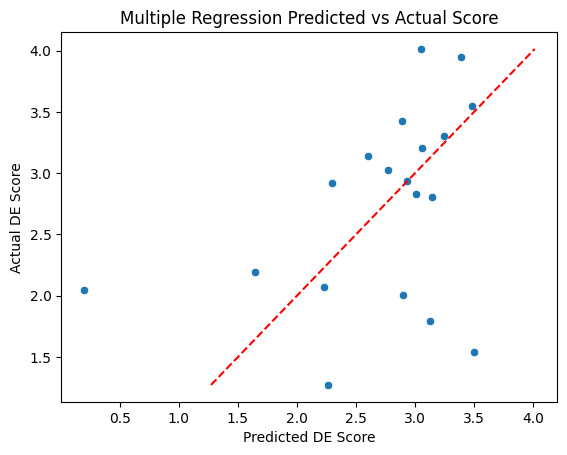

In [286]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_LR, y=y_test_path)

# Add a line for perfect correlation.
plt.plot([y_test_path.min(), y_test_path.max()],
         [y_test_path.min(), y_test_path.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Multiple Regression Predicted vs Actual Score')
plt.show()

In [287]:
#Run default Random Forest regression on dataset
RF = RandomForestRegressor()
RF.fit(X_train_path, y_train_path)
RF.score(X_train_path, y_train_path)

0.9180610269060815

In [288]:
#Determine MAE with test data
y_pred_RF = np.array(RF.predict(X_test_path))
y_pred_RF_score_paths = np.array(RF.predict(X_test_path))
mae_RF = mean_absolute_error(y_test_path, y_pred_RF)
mape_RF = mean_absolute_percentage_error(y_test_path, y_pred_RF)
print(f'Random Forest Regression MAE: {mae_RF}')

Random Forest Regression MAE: 0.4776580736414983


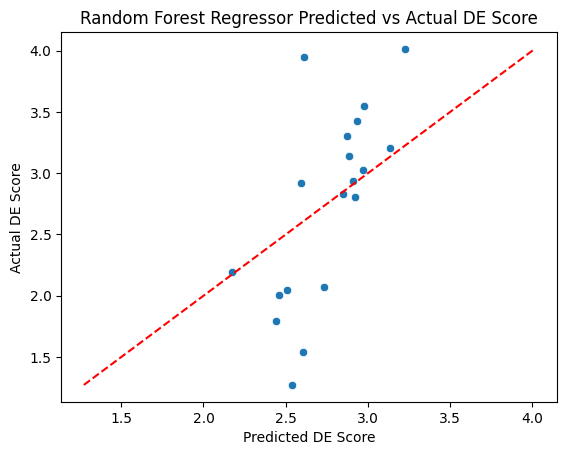

In [289]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_RF, y=y_test_path)

# Add a line for perfect correlation.
plt.plot([y_test_path.min(), y_test_path.max()],
         [y_test_path.min(), y_test_path.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Random Forest Regressor Predicted vs Actual DE Score')
plt.show()

In [290]:
#Run default Grandient Boosting regression on dataset
GB = GradientBoostingRegressor()
GB.fit(X_train_path, y_train_path)
GB.score(X_train_path, y_train_path)

0.999622727136566

In [291]:
#Determine MAE with test data
y_pred_GB = np.array(GB.predict(X_test_path))
mae_GB = mean_absolute_error(y_test_path, y_pred_GB)
mape_GB = mean_absolute_percentage_error(y_test_path, y_pred_GB)
print(f'Grandient Boosting Regression MAE: {mae_GB}')

Grandient Boosting Regression MAE: 0.47410785011958095


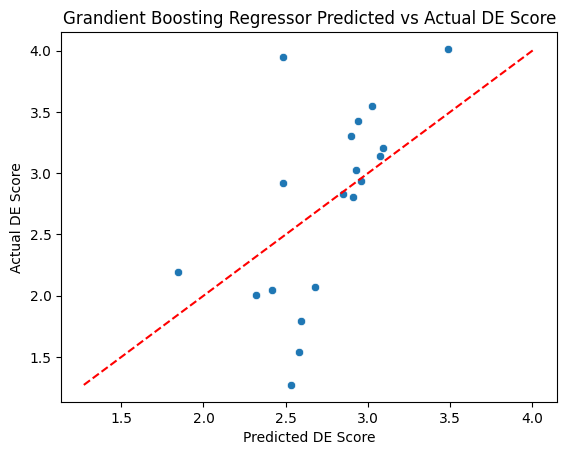

In [292]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_GB, y=y_test_path)

# Add a line for perfect correlation.
plt.plot([y_test_path.min(), y_test_path.max()],
         [y_test_path.min(), y_test_path.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Grandient Boosting Regressor Predicted vs Actual DE Score')
plt.show()

In [293]:
#Run default XGBoost regression on dataset
XG = XGBRegressor()
XG.fit(X_train_path, y_train_path)
XG.score(X_train_path, y_train_path)

0.9999994649775835

In [294]:
#Determine MAE with test data
y_pred_XG = np.array(XG.predict(X_test_path))
mae_XG = mean_absolute_error(y_test_path, y_pred_XG)
mape_XG = mean_absolute_percentage_error(y_test_path, y_pred_XG)
print(f'XGBoost Regression MAE: {mae_XG}')

XGBoost Regression MAE: 0.5322624887899718


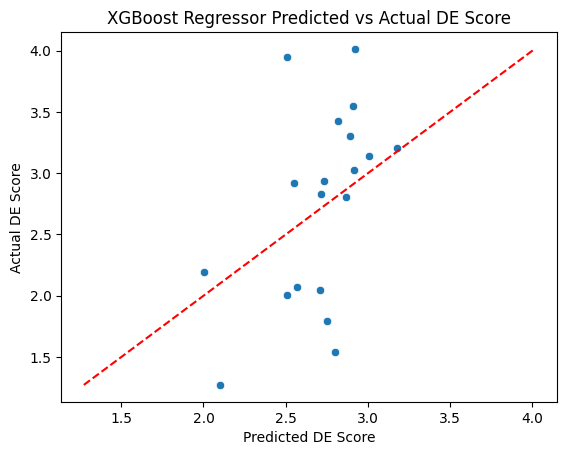

In [295]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_XG, y=y_test_path)

# Add a line for perfect correlation.
plt.plot([y_test_path.min(), y_test_path.max()],
         [y_test_path.min(), y_test_path.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('XGBoost Regressor Predicted vs Actual DE Score')
plt.show()

In [296]:
#Run default CatBoost regression on dataset
CB = CatBoostRegressor()
CB.fit(X_train_path, y_train_path)
CB.score(X_train_path, y_train_path)

Learning rate set to 0.027076
0:	learn: 0.5671925	total: 2.68ms	remaining: 2.68s
1:	learn: 0.5613828	total: 4.2ms	remaining: 2.1s
2:	learn: 0.5572395	total: 5.54ms	remaining: 1.84s
3:	learn: 0.5525826	total: 6.91ms	remaining: 1.72s
4:	learn: 0.5480339	total: 8.19ms	remaining: 1.63s
5:	learn: 0.5429579	total: 9.8ms	remaining: 1.62s
6:	learn: 0.5386095	total: 12.1ms	remaining: 1.71s
7:	learn: 0.5350248	total: 14.2ms	remaining: 1.76s
8:	learn: 0.5305351	total: 15.6ms	remaining: 1.72s
9:	learn: 0.5256792	total: 18.7ms	remaining: 1.85s
10:	learn: 0.5215186	total: 20.3ms	remaining: 1.82s
11:	learn: 0.5185829	total: 22.5ms	remaining: 1.85s
12:	learn: 0.5142013	total: 25.9ms	remaining: 1.97s
13:	learn: 0.5096063	total: 29.4ms	remaining: 2.07s
14:	learn: 0.5058600	total: 32.1ms	remaining: 2.11s
15:	learn: 0.5013887	total: 34.4ms	remaining: 2.11s
16:	learn: 0.4969815	total: 36.2ms	remaining: 2.09s
17:	learn: 0.4931429	total: 38ms	remaining: 2.07s
18:	learn: 0.4892105	total: 39.5ms	remaining: 2.0

np.float64(0.999998192102737)

In [297]:
#Determine MAE with test data
y_pred_CB = np.array(CB.predict(X_test_path))
y_pred_CB_score_paths = np.array(CB.predict(X_test_path))
mae_CB = mean_absolute_error(y_test_path, y_pred_CB)
mape_CB = mean_absolute_percentage_error(y_test_path, y_pred_CB)
print(f'Grandient Boosting Regression MAE: {mae_CB}')

Grandient Boosting Regression MAE: 0.5109905037535393


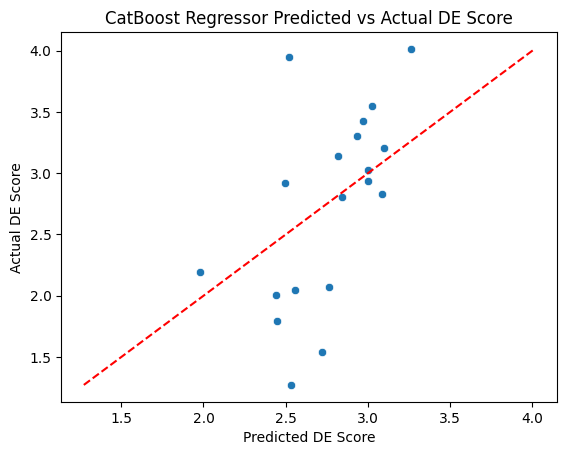

In [298]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_CB, y=y_test_path)

# Add a line for perfect correlation.
plt.plot([y_test_path.min(), y_test_path.max()],
         [y_test_path.min(), y_test_path.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('CatBoost Regressor Predicted vs Actual DE Score')
plt.show()

In [299]:
MAE_dict = {'Multiple Linear Regression': mae_LR, 'Random Forest Regressor': mae_RF, 'Gradient Boost Regressor': mae_GB, 'XGBoost Regressor': mae_XG, 'CatBoost Regressor': mae_CB}
MAPE_dict = {'Multiple Linear Regression': mape_LR, 'Random Forest Regressor': mape_RF, 'Gradient Boost Regressor': mape_GB, 'XGBoost Regressor': mape_XG, 'CatBoost Regressor': mape_CB}
Rsquared_dict = {'Multiple Linear Regression': LR.score(X_train_path, y_train_path), 'Random Forest Regressor': RF.score(X_train_path, y_train_path), 'Gradient Boost Regressor': GB.score(X_train_path, y_train_path),
                 'XGBoost Regressor': XG.score(X_train_path, y_train_path), 'CatBoost Regressor': CB.score(X_train_path, y_train_path)}
summary_pathways_score = pd.DataFrame({'MAE': MAE_dict, 'MAPE': MAPE_dict, 'R²': Rsquared_dict})
summary_pathways_score

,MAE,MAPE,R²
Multiple Linear Regression,0.630935,0.302210,0.926234
Random Forest Regressor,0.477658,0.215585,0.918061
Gradient Boost Regressor,0.474108,0.216221,0.999623
XGBoost Regressor,0.532262,0.230050,0.999999
CatBoost Regressor,0.510991,0.230386,0.999998


####Predicting Pseudorank

In [300]:
X = donor_pathways.drop(columns=['DEscore_long', 'DEscore_short', 'pseudorank'])
y = donor_pathways['pseudorank']

X_train_path, X_test_path, y_train_path, y_test_path = train_test_split(X, y, test_size=0.2, random_state=12)

In [301]:
#Run default linear regression on dataset
LR = LinearRegression()
LR.fit(X_train_path, y_train_path)
LR.score(X_train_path, y_train_path)

0.856043043276243

In [302]:
#Determine MAE with test data
y_pred_LR = np.array(LR.predict(X_test_path))
mae_LR = mean_absolute_error(y_test_path, y_pred_LR)
mape_LR = mean_absolute_percentage_error(y_test_path, y_pred_LR)
print(f'Linear Regression MAE: {mae_LR}')

Linear Regression MAE: 0.03678222059441476


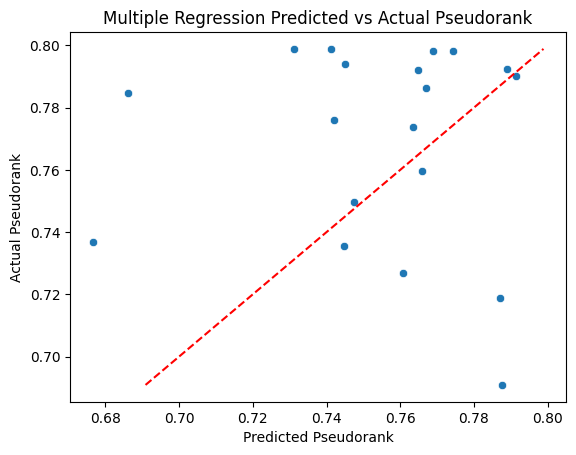

In [303]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_LR, y=y_test_path)

# Add a line for perfect correlation.
plt.plot([y_test_path.min(), y_test_path.max()],
         [y_test_path.min(), y_test_path.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Multiple Regression Predicted vs Actual Pseudorank')
plt.show()

In [304]:
#Run default Random Forest regression on dataset
RF = RandomForestRegressor()
RF.fit(X_train_path, y_train_path)
RF.score(X_train_path, y_train_path)

0.8853698947228643

In [305]:
#Determine MAE with test data
y_pred_RF = np.array(RF.predict(X_test_path))
y_pred_RF_rank_paths = np.array(RF.predict(X_test_path))
mae_RF = mean_absolute_error(y_test_path, y_pred_RF)
mape_RF = mean_absolute_percentage_error(y_test_path, y_pred_RF)
print(f'Random Forest Regression MAE: {mae_RF}')

Random Forest Regression MAE: 0.02023346267248455


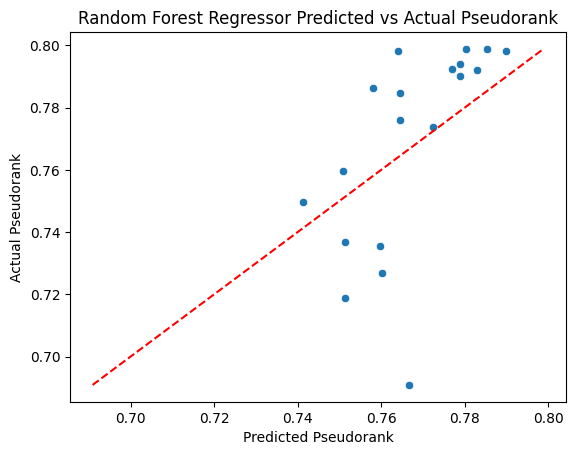

In [306]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_RF, y=y_test_path)

# Add a line for perfect correlation.
plt.plot([y_test_path.min(), y_test_path.max()],
         [y_test_path.min(), y_test_path.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Random Forest Regressor Predicted vs Actual Pseudorank')
plt.show()

In [307]:
#Run default Grandient Boosting regression on dataset
GB = GradientBoostingRegressor()
GB.fit(X_train_path, y_train_path)
GB.score(X_train_path, y_train_path)

0.9997597306730636

In [308]:
#Determine MAE with test data
y_pred_GB = np.array(GB.predict(X_test_path))
mae_GB = mean_absolute_error(y_test_path, y_pred_GB)
mape_GB = mean_absolute_percentage_error(y_test_path, y_pred_GB)
print(f'Grandient Boosting Regression MAE: {mae_GB}')

Grandient Boosting Regression MAE: 0.019064126878448086


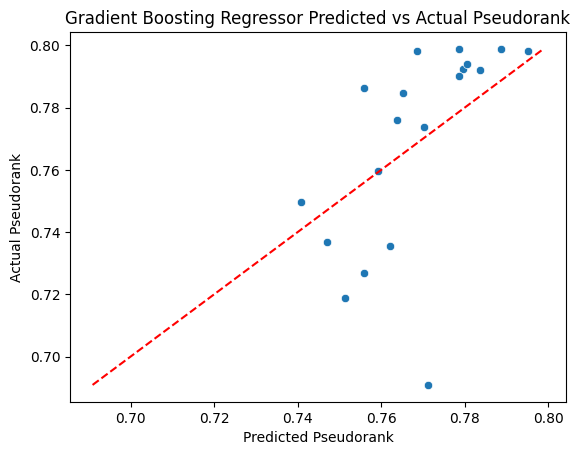

In [309]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_GB, y=y_test_path)

# Add a line for perfect correlation.
plt.plot([y_test_path.min(), y_test_path.max()],
         [y_test_path.min(), y_test_path.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Gradient Boosting Regressor Predicted vs Actual Pseudorank')
plt.show()

In [310]:
#Run default XGBoost regression on dataset
XG = XGBRegressor()
XG.fit(X_train_path, y_train_path)
XG.score(X_train_path, y_train_path)

0.9996902942657471

In [311]:
#Determine MAE with test data
y_pred_XG = np.array(XG.predict(X_test_path))
mae_XG = mean_absolute_error(y_test_path, y_pred_XG)
mape_XG = mean_absolute_percentage_error(y_test_path, y_pred_XG)
print(f'XGBoost Regression MAE: {mae_XG}')

XGBoost Regression MAE: 0.021313892677426338


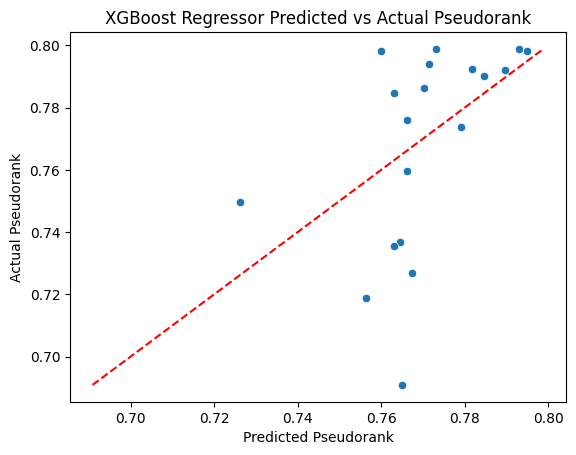

In [312]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_XG, y=y_test_path)

# Add a line for perfect correlation.
plt.plot([y_test_path.min(), y_test_path.max()],
         [y_test_path.min(), y_test_path.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('XGBoost Regressor Predicted vs Actual Pseudorank')
plt.show()

In [313]:
#Run default CatBoost regression on dataset
CB = CatBoostRegressor()
CB.fit(X_train_path, y_train_path)
CB.score(X_train_path, y_train_path)

Learning rate set to 0.027076
0:	learn: 0.0234627	total: 2.04ms	remaining: 2.04s
1:	learn: 0.0232710	total: 3.47ms	remaining: 1.73s
2:	learn: 0.0230782	total: 4.79ms	remaining: 1.59s
3:	learn: 0.0229289	total: 6.42ms	remaining: 1.6s
4:	learn: 0.0226926	total: 7.88ms	remaining: 1.57s
5:	learn: 0.0225316	total: 9.38ms	remaining: 1.55s
6:	learn: 0.0223165	total: 11.1ms	remaining: 1.57s
7:	learn: 0.0221499	total: 12.6ms	remaining: 1.56s
8:	learn: 0.0219586	total: 14.3ms	remaining: 1.58s
9:	learn: 0.0217767	total: 15.7ms	remaining: 1.56s
10:	learn: 0.0215806	total: 17ms	remaining: 1.53s
11:	learn: 0.0213960	total: 18.4ms	remaining: 1.51s
12:	learn: 0.0212753	total: 19.8ms	remaining: 1.5s
13:	learn: 0.0211522	total: 21.1ms	remaining: 1.49s
14:	learn: 0.0209138	total: 22.5ms	remaining: 1.48s
15:	learn: 0.0207622	total: 23.9ms	remaining: 1.47s
16:	learn: 0.0206038	total: 26.2ms	remaining: 1.51s
17:	learn: 0.0204066	total: 27.8ms	remaining: 1.52s
18:	learn: 0.0202193	total: 29.2ms	remaining: 1.

np.float64(0.999996933294098)

In [314]:
#Determine MAE with test data
y_pred_CB = np.array(CB.predict(X_test_path))
y_pred_CD_rank_paths = np.array(CB.predict(X_test_path))
mae_CB = mean_absolute_error(y_test_path, y_pred_CB)
mape_CB = mean_absolute_percentage_error(y_test_path, y_pred_CB)
print(f'Grandient Boosting Regression MAE: {mae_CB}')

Grandient Boosting Regression MAE: 0.01903250725879303


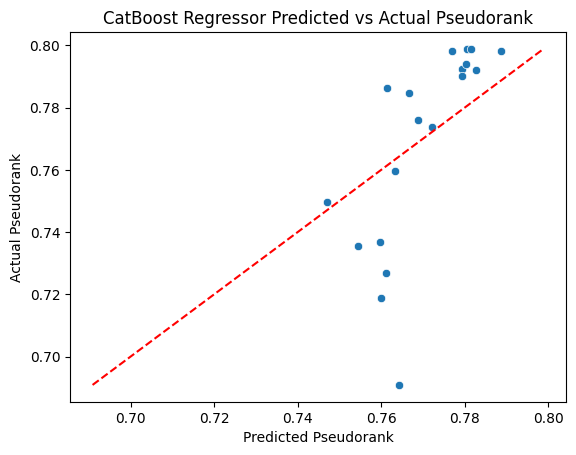

In [315]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_CB, y=y_test_path)

# Add a line for perfect correlation.
plt.plot([y_test_path.min(), y_test_path.max()],
         [y_test_path.min(), y_test_path.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('CatBoost Regressor Predicted vs Actual Pseudorank')
plt.show()

In [316]:
MAE_dict = {'Multiple Linear Regression': mae_LR, 'Random Forest Regressor': mae_RF, 'Gradient Boost Regressor': mae_GB, 'XGBoost Regressor': mae_XG, 'CatBoost Regressor': mae_CB}
MAPE_dict = {'Multiple Linear Regression': mape_LR, 'Random Forest Regressor': mape_RF, 'Gradient Boost Regressor': mape_GB, 'XGBoost Regressor': mape_XG, 'CatBoost Regressor': mape_CB}
Rsquared_dict = {'Multiple Linear Regression': LR.score(X_train_path, y_train_path), 'Random Forest Regressor': RF.score(X_train_path, y_train_path), 'Gradient Boost Regressor': GB.score(X_train_path, y_train_path),
                 'XGBoost Regressor': XG.score(X_train_path, y_train_path), 'CatBoost Regressor': CB.score(X_train_path, y_train_path)}
summary_pathways_rank = pd.DataFrame({'MAE': MAE_dict, 'MAPE': MAPE_dict, 'R²': Rsquared_dict})
summary_pathways_rank

,MAE,MAPE,R²
Multiple Linear Regression,0.036782,0.048444,0.856043
Random Forest Regressor,0.020233,0.026956,0.885370
Gradient Boost Regressor,0.019064,0.025477,0.999760
XGBoost Regressor,0.021314,0.028511,0.999690
CatBoost Regressor,0.019033,0.025454,0.999997


####Summary of Model Screening

In [317]:
summary_merged = pd.concat([summary_genes_score.add_prefix('genes_DE_'),
                            summary_genes_rank.add_prefix('genes_PR_'),
                            summary_pathways_score.add_prefix('pathways_DE_'),
                            summary_pathways_rank.add_prefix('pathways_PR_')], axis=1)

summary_merged

,genes_DE_MAE,genes_DE_MAPE,genes_DE_R²,genes_PR_MAE,genes_PR_MAPE,genes_PR_R²,pathways_DE_MAE,pathways_DE_MAPE,pathways_DE_R²,pathways_PR_MAE,pathways_PR_MAPE,pathways_PR_R²
Multiple Linear Regression,0.568602,0.204038,1.000000,0.047347,0.062277,1.000000,0.630935,0.302210,0.926234,0.036782,0.048444,0.856043
Random Forest Regressor,0.404805,0.151211,0.923896,0.016204,0.021715,0.915313,0.477658,0.215585,0.918061,0.020233,0.026956,0.885370
Gradient Boost Regressor,0.401236,0.150670,0.999810,0.015706,0.021009,0.999902,0.474108,0.216221,0.999623,0.019064,0.025477,0.999760
XGBoost Regressor,0.456879,0.173794,1.000000,0.016859,0.022656,0.999780,0.532262,0.230050,0.999999,0.021314,0.028511,0.999690
CatBoost Regressor,0.410011,0.153956,0.999999,0.015049,0.020189,0.999999,0.510991,0.230386,0.999998,0.019033,0.025454,0.999997


The above summary table has a lot of information, so I'll make a smaller tables for the MAE and MAPE to help with comparisons.  The R2 values are pretty consisttent accross learners, so we will leave those for now.

In [318]:
summary_merged_MAE = summary_merged[['genes_DE_MAE', 'genes_PR_MAE', 'pathways_DE_MAE', 'pathways_PR_MAE']]
summary_merged_MAE

,genes_DE_MAE,genes_PR_MAE,pathways_DE_MAE,pathways_PR_MAE
Multiple Linear Regression,0.568602,0.047347,0.630935,0.036782
Random Forest Regressor,0.404805,0.016204,0.477658,0.020233
Gradient Boost Regressor,0.401236,0.015706,0.474108,0.019064
XGBoost Regressor,0.456879,0.016859,0.532262,0.021314
CatBoost Regressor,0.410011,0.015049,0.510991,0.019033


From this summary of MAE, we learn the following:

1) MAE for PR predictions are way lower than for DE predictions.  This is partly due to the different scales between PR and DE, with DE being about 5x higher that PR, but the difference between MAE is closer to 20x.  We'll use MAPE to better compare predictions of PR and DE.
2) Predictions based on the correlating genes is marginally better than predicting with gene pathways.
3) Best Learners: CatBoost

Note: I ran the model screening with a few different splits by changing the ranndom state seed and the MAE differneces between best learners (excluding Multiple Regression) are smaller than the MAE diffences with the same learner working with different splits (more on this below).  CatBoost genes_PR_MAE varied from 0.022 to 0.009 with my tests.  Random Forest and CatBoost were usually the best, but not every time.

In [319]:
summary_merged_MAPE = summary_merged[['genes_DE_MAPE', 'genes_PR_MAPE', 'pathways_DE_MAPE', 'pathways_PR_MAPE']]
summary_merged_MAPE

,genes_DE_MAPE,genes_PR_MAPE,pathways_DE_MAPE,pathways_PR_MAPE
Multiple Linear Regression,0.204038,0.062277,0.302210,0.048444
Random Forest Regressor,0.151211,0.021715,0.215585,0.026956
Gradient Boost Regressor,0.150670,0.021009,0.216221,0.025477
XGBoost Regressor,0.173794,0.022656,0.230050,0.028511
CatBoost Regressor,0.153956,0.020189,0.230386,0.025454


From this summary of MAPE, we learn the following:

1) We confirm that predictions from PR are better than predictions from DE, as a percentage of the target values.  MAPE for DE is 5-10x higher than for PR.
2) Best Learners overall: Random Forest and CatBoost using genes to predict PR.

Another approach to evaluating these models is to see how their predictions rank the donors relative to the actual order.  The most plausible 'real world' application of this type of model would be to select the top 5-10 donors for for validation in the lab.  We will look at this in the next section.

##Assessing Donor Order

To visualize this donor ranking, I'll use a slope chart comparing actual donor order to the new order based on predictions using Random Forest and CatBoost predictions from gene datasets.

In [320]:
donor_order_RF = pd.DataFrame({'actual_pr':y_test_rank,
                               'actual_de':y_test_score,
                               'pred_rank_genes':pd.Series(y_pred_RF_rank_genes, index=y_test_rank.index),
                               'pred_score_genes':pd.Series(y_pred_RF_score_genes, index=y_test_score.index)})
donor_order_CB = pd.DataFrame({'actual_pr':y_test_rank,
                               'actual_de':y_test_score,
                               'pred_rank_genes':pd.Series(y_pred_CB_rank_genes, index=y_test_rank.index),
                               'pred_score_genes':pd.Series(y_pred_CB_score_genes, index=y_test_score.index)})
donor_order_RF.head()

,actual_pr,actual_de,pred_rank_genes,pred_score_genes
rayr,0.792530,3.218158,0.785703,3.095376
vazt,0.737484,3.227794,0.755258,3.104945
yelp,0.798859,2.939669,0.793919,3.298254
iiyk,0.768312,2.857949,0.758013,2.408353
zapk,0.719840,2.296221,0.765130,2.960604


In [321]:
donor_order_rank = pd.DataFrame({'actual_pr':y_test_rank,
                                 'pred_RF':pd.Series(y_pred_RF_rank_genes, index=y_test_rank.index),
                                 'pred_CB':pd.Series(y_pred_CB_rank_genes, index=y_test_rank.index)})
donor_order_score = pd.DataFrame({'actual_de':y_test_score,
                               'pred_RF':pd.Series(y_pred_RF_score_genes, index=y_test_score.index),
                               'pred_CB':pd.Series(y_pred_CB_score_genes, index=y_test_score.index)})
donor_order_rank.head()

,actual_pr,pred_RF,pred_CB
rayr,0.792530,0.785703,0.789651
vazt,0.737484,0.755258,0.753733
yelp,0.798859,0.793919,0.791750
iiyk,0.768312,0.758013,0.766267
zapk,0.719840,0.765130,0.765984


In [322]:
def slope_chart(data, left_col, right_col, title):
  left=data[left_col].dropna()
  right=data[right_col].dropna()
  donors=data.dropna().index
  fig, ax = plt.subplots(figsize=(6,8))
  for donor in donors:
    ax.plot([0,1],[left.loc[donor], right.loc[donor]], marker='o', linewidth=1)
  ax.set_xticks([0,1])
  ax.set_xticklabels([left_col, right_col])
  ax.set_xlim(-0.1,1.1)
  ax.invert_yaxis()
  ax.set_ylabel('Rank')
  ax.set_title(title)
  plt.tight_layout()
  plt.show()

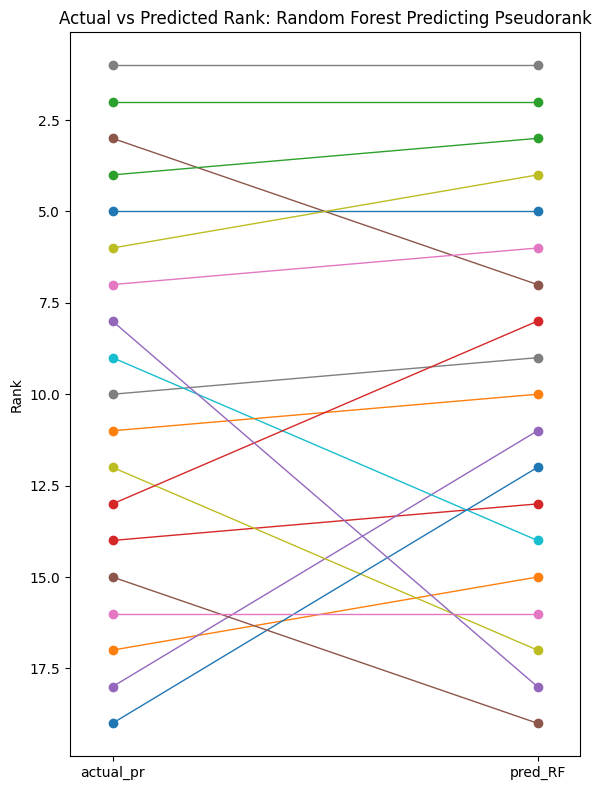

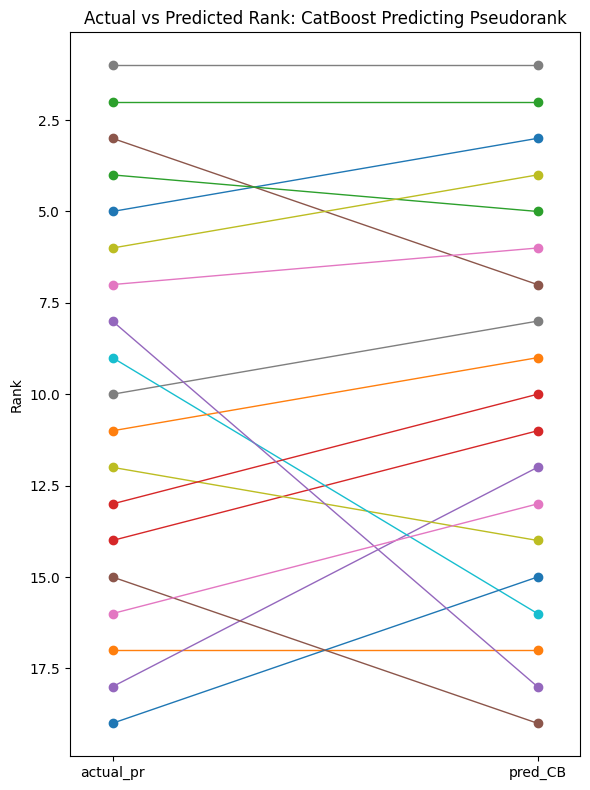

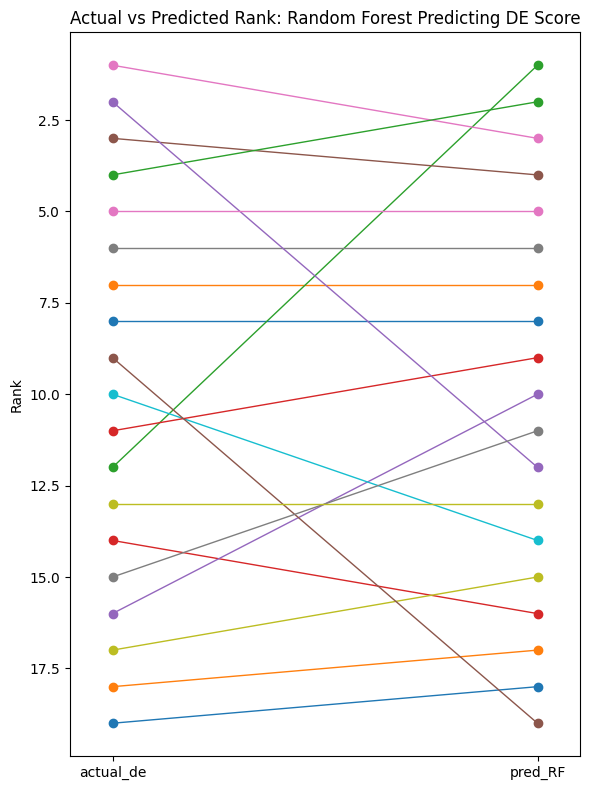

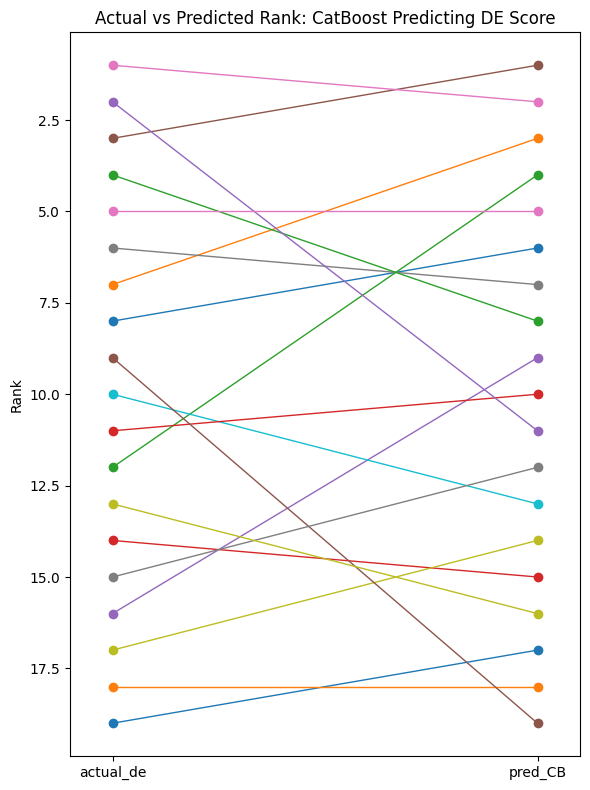

In [323]:
rank_PR = donor_order_rank.rank(ascending=False)
rank_DE = donor_order_score.rank(ascending=False)

slope_chart(rank_PR, 'actual_pr', 'pred_RF', 'Actual vs Predicted Rank: Random Forest Predicting Pseudorank')
slope_chart(rank_PR, 'actual_pr', 'pred_CB', 'Actual vs Predicted Rank: CatBoost Predicting Pseudorank')
slope_chart(rank_DE, 'actual_de', 'pred_RF', 'Actual vs Predicted Rank: Random Forest Predicting DE Score')
slope_chart(rank_DE, 'actual_de', 'pred_CB', 'Actual vs Predicted Rank: CatBoost Predicting DE Score')

These look pretty good - all four are to pull out the best donors and get the correct order at the top of our list.  Next, I'll look at some statistical metrics of these ranking systems.

In [324]:
def compare_ranks(data1, data2):
  spearman = spearmanr(data1, data2).statistic
  tau = kendalltau(data1, data2).statistic
  mean_rank_error = (data1 - data2).abs().mean()
  return spearman, tau, mean_rank_error

def top_five_overlap(data1, data2):
  top_five_actual = set(data1.nsmallest(5).index)
  top_five_predicted = set(data2.nsmallest(5).index)
  common = top_five_actual.intersection(top_five_predicted)
  return common

def top_three_overlap(data1, data2):
  top_three_actual = set(data1.nsmallest(3).index)
  top_three_predicted = set(data2.nsmallest(3).index)
  common = top_three_actual.intersection(top_three_predicted)
  return common

In [325]:
print(top_five_overlap(rank_PR['actual_pr'], rank_PR['pred_RF']),
      top_five_overlap(rank_PR['actual_pr'], rank_PR['pred_CB']),
      top_five_overlap(rank_DE['actual_de'], rank_DE['pred_RF']),
      top_five_overlap(rank_DE['actual_de'], rank_DE['pred_CB']))

{'yelp', 'rayr', 'zagm', 'hegp'} {'yelp', 'rayr', 'zagm', 'hegp'} {'tolg', 'aowh', 'zagm', 'sohd'} {'tolg', 'aowh', 'sohd'}


In [326]:
print(top_three_overlap(rank_PR['actual_pr'], rank_PR['pred_RF']),
      top_three_overlap(rank_PR['actual_pr'], rank_PR['pred_CB']),
      top_three_overlap(rank_DE['actual_de'], rank_DE['pred_RF']),
      top_three_overlap(rank_DE['actual_de'], rank_DE['pred_CB']))

{'yelp', 'hegp'} {'yelp', 'hegp'} {'tolg'} {'tolg', 'aowh'}


This tells us that the models predicting PR are able to find 4 of the top 5 donors correctly. Finding the top three is less reliable, but Catboost did a better job at this than Random Forest.  CatBoost predicting PR found 2 of the top 3.  This suggests that models would succeed at getting the right donors selected for validation in the lab. Models predicting DE were less accurate.

In [327]:
spearman, tau, mean_rank_error = compare_ranks(rank_PR['actual_pr'], rank_PR['pred_RF'])
print(f'Random Forest ranking of Psueodorank - Spearman: {spearman}')
print(f'Random Forest ranking of Psueodorank - Kendall Tau: {tau}')
print(f'Random Forest ranking of Psueodorank - Mean Rank Error: {mean_rank_error}')

Random Forest ranking of Psueodorank - Spearman: 0.7210526315789473
Random Forest ranking of Psueodorank - Kendall Tau: 0.5321637426900584
Random Forest ranking of Psueodorank - Mean Rank Error: 2.9473684210526314


In [328]:
spearman, tau, mean_rank_error = compare_ranks(rank_PR['actual_pr'], rank_PR['pred_CB'])
print(f'CatBoost ranking of Psueodorank - Spearman: {spearman}')
print(f'CatBoost ranking of Psueodorank - Kendall Tau: {tau}')
print(f'CatBoost ranking of Psueodorank - Mean Rank Error: {mean_rank_error}')

CatBoost ranking of Psueodorank - Spearman: 0.7526315789473684
CatBoost ranking of Psueodorank - Kendall Tau: 0.5906432748538012
CatBoost ranking of Psueodorank - Mean Rank Error: 2.9473684210526314


In [329]:
spearman, tau, mean_rank_error = compare_ranks(rank_DE['actual_de'], rank_DE['pred_RF'])
print(f'Random Forest ranking of DE Score - Spearman: {spearman}')
print(f'Random Forest ranking of DE Score - Kendall Tau: {tau}')
print(f'Random Forest ranking of DE Score - Mean Rank Error: {mean_rank_error}')

Random Forest ranking of DE Score - Spearman: 0.6385964912280702
Random Forest ranking of DE Score - Kendall Tau: 0.52046783625731
Random Forest ranking of DE Score - Mean Rank Error: 3.0526315789473686


In [330]:
spearman, tau, mean_rank_error = compare_ranks(rank_DE['actual_de'], rank_DE['pred_CB'])
print(f'CatBoost ranking of DE Score - Spearman: {spearman}')
print(f'CatBoost ranking of DE Score - Kendall Tau: {tau}')
print(f'CatBoost ranking of DE Score - Mean Rank Error: {mean_rank_error}')

CatBoost ranking of DE Score - Spearman: 0.6684210526315789
CatBoost ranking of DE Score - Kendall Tau: 0.4619883040935673
CatBoost ranking of DE Score - Mean Rank Error: 3.3684210526315788


The above metrics look at the ranking over the entire test set, not just the top. Here again, the models predicting PR do better than models predicting DE.  The Random Forest and CatBoost learners places donors an average of 2.5 ranks away from their actual rank and got the top two donors correct.  However, CatBoost had slightly better Spearman and Kendall Coefficients and did better at ordering donors over different splits (data not show, done by changing the random state seed and running multiple times) lead us to select CatBoost as our learner for the final model.

##Model Building: Final Steps

I the previous section, we selected the CatBoost learner, prediciting donor pseudorank as our preffered model.  We have selected hot to do Hyperparameter tuning as the risk of overfitting outweights the potential benefit of moderate improvements to the existing model.

As a final step, we will refine out features selection.  The existing model was made from the top 100 genes correlating with donor pseudorank. In the following we will optimize gene number, starting from the top 200 genes.

### With CB selection

Instead of selecting genes based on a linear correlation with pseudorank, it is better practice to select features using a tree based model.  Here we will use CatBoost Rgressor to pick out the best 100 genes in place of the dataset we created earlier and see if this improves our model.



In [345]:
#To verify that the donor_adata.layers['counts'] are still the raw counts, find the max value (should be large)
donor_adata.layers['counts'].max()

np.float64(4477677.06230918)

In [331]:
donor_adata.X = donor_adata.layers['counts']
X = pd.DataFrame(donor_adata.X, columns=donor_adata.var_names, index=donor_adata.obs_names)
y_pr = donor_adata.obs['pseudorank']

X_train, X_test, y_train_pr, y_test_pr = train_test_split(X, y_pr, test_size=0.2, random_state=42)
X_train = normalize_log(X_train)
X_test = normalize_log(X_test)

In [332]:
CB_full = CatBoostRegressor(verbose=0)
CB_full.fit(X_train, y_train_pr)
y_pred_full = CB_full.predict(X_test)
import shap

explainer = shap.TreeExplainer(CB_full)
shap_values = explainer.shap_values(X_train)

shap_importance = np.abs(shap_values).mean(axis=0)
shap_rank = pd.Series(shap_importance, index=X_train.columns).sort_values(ascending=False)

In [333]:
# Loop through features lists of the top 50 to 100 features to determine how many features are needed to maintain MAE in the Random Forest learner.
MAE_full = []
for i in range(5, 101, 5):
    X_train_short = X_train[shap_rank.index[:i]]
    X_test_short = X_test[shap_rank.index[:i]]
    CB_short = CatBoostRegressor(verbose=0)
    CB_short.fit(X_train_short, y_train_pr)
    y_pred_CBshort = CB_short.predict(X_test_short)
    y_pred_CBshort=np.asarray(y_pred_CBshort).ravel()
    mae_short = mean_absolute_error(y_test_pr, y_pred_CBshort)
    MAE_full.append(mae_short)

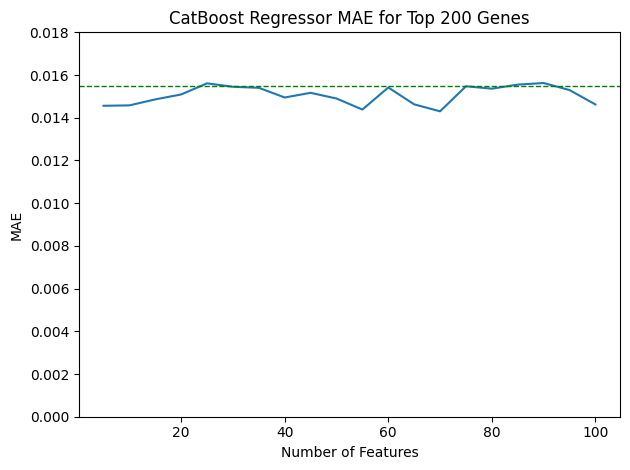

In [334]:
features = range(5, 101, 5)
summary_features = pd.DataFrame({'MAE':MAE_full}, index=features)
sns.lineplot(data=summary_features, x=features, y='MAE')
plt.title('CatBoost Regressor MAE for Top 200 Genes')
plt.xlabel('Number of Features')
plt.ylabel('MAE')
plt.axhline(y=0.0155, color='green', linestyle='--', linewidth=1)
plt.ylim(ymin=0, ymax=0.018)
plt.tight_layout()
plt.show()

These models all have an error around what we found with our 100 correlating genes, but there seems to be a lower error with smaller features numbers.  I'll repeat this with 1-20 features.

In [335]:
# Loop through features lists of the top 1 to 20 features to determine how many features are needed to maintain MAE in the CatBoost learner.
MAE_short = []
for i in range(1, 21, 1):
    X_train_short = X_train[shap_rank.index[:i]]
    X_test_short = X_test[shap_rank.index[:i]]
    CB_short = CatBoostRegressor(verbose=0)
    CB_short.fit(X_train_short, y_train_pr)
    y_pred_CBshort = CB_short.predict(X_test_short)
    y_pred_CBshort=np.asarray(y_pred_CBshort).ravel()
    mae_short = mean_absolute_error(y_test_pr, y_pred_CBshort)
    MAE_short.append(mae_short)

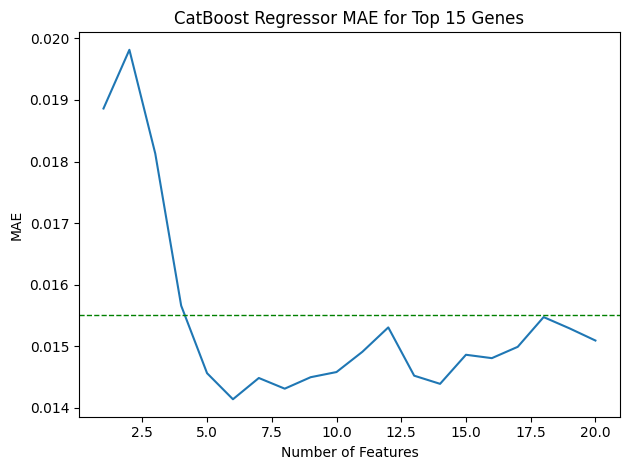

In [336]:
features_short = range(1, 21, 1)
summary_short = pd.DataFrame({'MAE':MAE_short}, index=features_short)

sns.lineplot(data=summary_short, x=features_short, y='MAE')
plt.axhline(y=0.0155, color='green', linestyle='--', linewidth=1)
plt.title('CatBoost Regressor MAE for Top 15 Genes')
plt.xlabel('Number of Features')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

This gives us a better idea of what is going on - the lowest MAE is 5-7 genes.  The error is consistently lower than we saw with our previous gene list (although I did have splits that got a lower error). Let's make a new dataset with the top 100 genes and do feature selection over multiple splits.

In [337]:
shap_rank_100 = shap_rank[0:100]
donor_rank_100 = donor_adata[:, shap_rank_100.index].copy()

###Feature Refinement Using Optimized Set of 100 genes

As the attempt with gene selection using a model to pick from the list of 11,000 was unsuccessful, we will go back to our gene lists based on correlation and try to further refine our feature selection.


In [346]:
#To verify that the donor_rank_100.layers['counts'] are still the raw counts, find the max value (should be large)
donor_rank_100.layers['counts'].max()

np.float64(759411.0718874728)

In [338]:
#Redo the split on this 'new' dataset
donor_rank_100.X = donor_rank_100.layers['counts'].copy()
X = pd.DataFrame(donor_rank_100.X, columns=donor_rank_100.var_names, index=donor_rank_100.obs_names)
y_pr = donor_adata.obs['pseudorank']

X_train, X_test, y_train_pr, y_test_pr = train_test_split(X, y_pr, test_size=0.2, random_state=42)
X_train = normalize_log(X_train)
X_test = normalize_log(X_test)

In [339]:
CB_100 = CatBoostRegressor(verbose=0)
CB_100.fit(X_train, y_train_pr)
y_pred_100 = CB_100.predict(X_test)
importances = CB_100.get_feature_importance() #Get feature importances
CB_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=False) #Sort genes in order of importance

In [340]:
# Loop through features lists of the top 5 to 100 features to determine how many features are needed to maintain MAE in the Random Forest learner.
MAE_100 = []
for i in range(5, 101, 5):
    X_train_short = X_train[CB_importances.index[:i]]
    X_test_short = X_test[CB_importances.index[:i]]
    CB_short = CatBoostRegressor(verbose=0)
    CB_short.fit(X_train_short, y_train_pr)
    y_pred_CBshort = CB_short.predict(X_test_short)
    y_pred_CBshort=np.asarray(y_pred_CBshort).ravel()
    mae_short = mean_absolute_error(y_test_pr, y_pred_CBshort)
    MAE_100.append(mae_short)

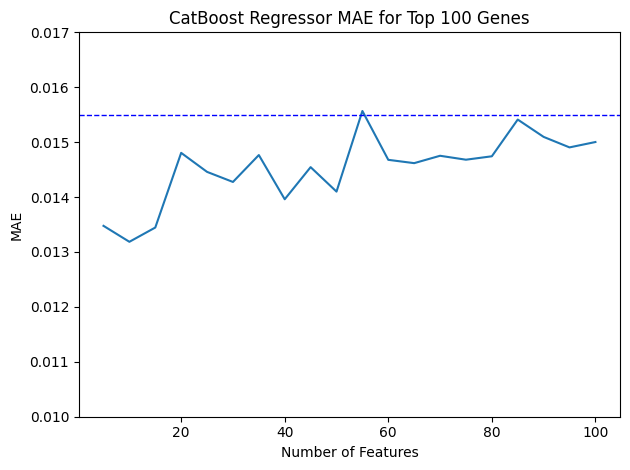

In [341]:
features = range(5, 101, 5)
summary_features = pd.DataFrame({'MAE':MAE_100}, index=features)

sns.lineplot(data=summary_features, x=features, y='MAE')
plt.axhline(y=0.0155, color='blue', linestyle='--', linewidth=1)
plt.title('CatBoost Regressor MAE for Top 100 Genes')
plt.xlabel('Number of Features')
plt.ylim(ymin=.010, ymax=0.017)
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

Our error is essentially the same as our MAE for model screening. This looks like wer are past the plateau phase, so I'll repeat this with smaller numbers of genes.

In [342]:
# Loop through features lists of the top 50 to 1000 features to determine how many features are needed to maintain MAE in the Random Forest learner.
MAE_short = []
for i in range(1, 21, 1):
    X_train_short = X_train[CB_importances.index[:i]]
    X_test_short = X_test[CB_importances.index[:i]]
    CB_short = CatBoostRegressor(verbose=0)
    CB_short.fit(X_train_short, y_train_pr)
    y_pred_CBshort = CB_short.predict(X_test_short)
    y_pred_CBshort=np.asarray(y_pred_CBshort).ravel()
    mae_short = mean_absolute_error(y_test_pr, y_pred_CBshort)
    MAE_short.append(mae_short)

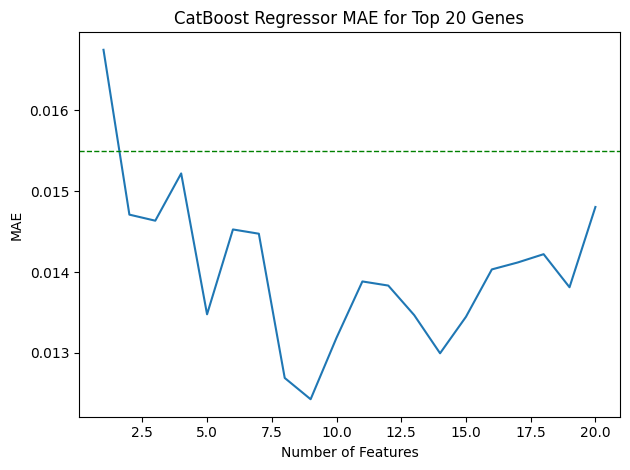

In [343]:
features_short = range(1, 21, 1)
summary_short = pd.DataFrame({'MAE':MAE_short}, index=features_short)

sns.lineplot(data=summary_short, x=features_short, y='MAE')
plt.axhline(y=0.0155, color='green', linestyle='--', linewidth=1)
plt.title('CatBoost Regressor MAE for Top 20 Genes')
plt.xlabel('Number of Features')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

With this split, the lowest error is with a model built on the top 8 or 9 genes.  Adding more genes leads to overfitting.

This is a surprisingly small number of genes.  Let's see how stable the error and the selected genes are over multiple splits.  We'll collect the MAE for each number of features on each split as well as the most important 6, 10 and 24 genes.

In [348]:
n_splits = 20
top_6 = 6
top_10 = 10
top_24 = 24

selected_gene_6 = {}
selected_gene_10 = {}
selected_gene_24 = {}
mae_all = {}

for seed in range(n_splits):
  print(f'Starting split {seed}')
  X_train, X_test, y_train, y_test = train_test_split(X, y_pr, test_size=0.2, random_state=seed) #Make Split
  X_train = normalize_log(X_train)
  X_test = normalize_log(X_test)
  full_model = CatBoostRegressor(verbose=0) #Fit full model
  full_model.fit(X_train, y_train)
  importances = full_model.get_feature_importance()
  importances_series = pd.Series(importances, index=X_train.columns).sort_values(ascending=False) #Calculate importances
  mae_split = []
  for i in range(1, 31, 1):
    selected_features = importances_series.head(i).index #Select top k genes
    X_train_short = X_train[selected_features]
    X_test_short = X_test[selected_features]
    model = CatBoostRegressor(verbose=0)
    model.fit(X_train_short, y_train)
    y_pred = model.predict(X_test_short)
    mae = mean_absolute_error(y_test, y_pred) #collect MAE
    mae_split.append(mae)
  mae_all[seed] = mae_split
  selected_gene_6[seed] = list(importances_series.head(top_6).index)
  selected_gene_10[seed] = list(importances_series.head(top_10).index)
  selected_gene_24[seed] = list(importances_series.head(top_24).index)

Starting split 0
Starting split 1
Starting split 2
Starting split 3
Starting split 4
Starting split 5
Starting split 6
Starting split 7
Starting split 8
Starting split 9
Starting split 10
Starting split 11
Starting split 12
Starting split 13
Starting split 14
Starting split 15
Starting split 16
Starting split 17
Starting split 18
Starting split 19


In [349]:
mae_all_df = pd.DataFrame.from_dict(mae_all, orient='index')
mae_all_df.index = [f"split_{i+1}" for i in mae_all_df.index]
mae_all_df.columns = [f"{i+1}_genes" for i in range(30)]
mae_all_df

,1_genes,2_genes,3_genes,4_genes,5_genes,6_genes,7_genes,8_genes,9_genes,10_genes,...,21_genes,22_genes,23_genes,24_genes,25_genes,26_genes,27_genes,28_genes,29_genes,30_genes
split_1,0.026971,0.021437,0.017401,0.017172,0.016934,0.017277,0.017694,0.017398,0.018269,0.017930,...,0.016468,0.016626,0.016836,0.016749,0.016650,0.016934,0.017432,0.017177,0.016511,0.016098
split_2,0.020155,0.016628,0.017287,0.018021,0.018395,0.017464,0.016315,0.015536,0.014900,0.014455,...,0.014228,0.013711,0.013852,0.014206,0.014126,0.013926,0.013648,0.014212,0.014374,0.014274
split_3,0.029419,0.020683,0.018503,0.017392,0.019030,0.017023,0.015019,0.016930,0.016202,0.016637,...,0.015957,0.016286,0.016408,0.016104,0.016224,0.016685,0.016294,0.016562,0.016313,0.016723
split_4,0.024051,0.020336,0.018263,0.018542,0.015952,0.014884,0.016726,0.015995,0.014232,0.014721,...,0.011264,0.011578,0.010875,0.011492,0.010963,0.011338,0.011423,0.011068,0.011025,0.011036
split_5,0.017556,0.017269,0.018118,0.013239,0.014929,0.013715,0.012029,0.011139,0.010441,0.010697,...,0.010255,0.009930,0.009618,0.009816,0.010057,0.010512,0.009628,0.009281,0.009259,0.009821
split_6,0.019513,0.012125,0.011643,0.011462,0.011265,0.009455,0.010795,0.012044,0.011599,0.011911,...,0.009963,0.010063,0.009971,0.010389,0.010207,0.010679,0.010694,0.010370,0.010933,0.010536
split_7,0.023141,0.018867,0.016192,0.017948,0.016435,0.015828,0.015898,0.015826,0.015733,0.015598,...,0.015929,0.015464,0.015874,0.015574,0.015473,0.015819,0.014978,0.014907,0.015464,0.014785
split_8,0.021047,0.017312,0.013719,0.014893,0.014189,0.015527,0.015873,0.016205,0.016550,0.016036,...,0.013866,0.014443,0.013563,0.014318,0.014364,0.014322,0.014208,0.014390,0.014975,0.015062
split_9,0.019495,0.016348,0.011601,0.010149,0.008300,0.008974,0.008900,0.009169,0.009236,0.008873,...,0.009141,0.009407,0.009573,0.010366,0.009312,0.009690,0.010051,0.009791,0.009765,0.009529
split_10,0.023209,0.018423,0.017403,0.015033,0.014831,0.013569,0.012725,0.013701,0.014409,0.014305,...,0.014137,0.013434,0.013464,0.014199,0.014209,0.014048,0.013249,0.013542,0.013254,0.012985


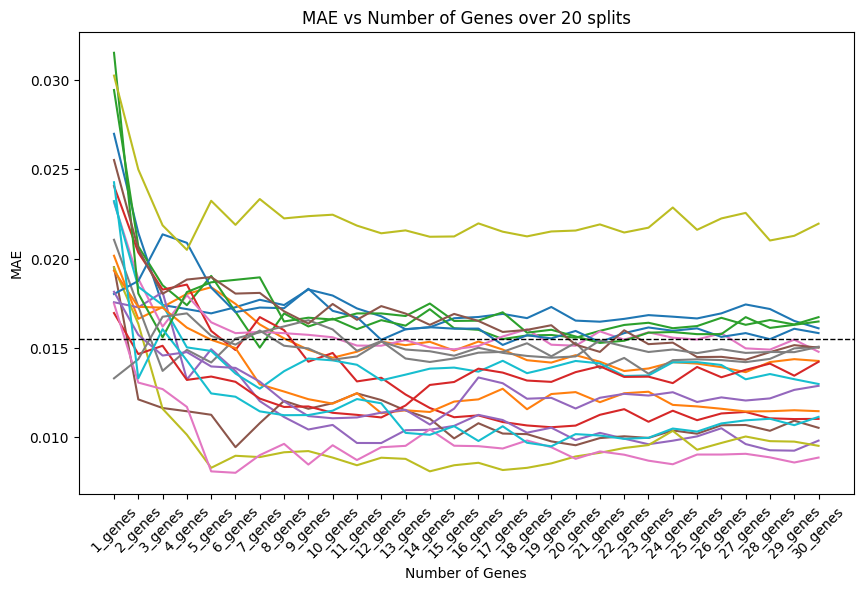

In [350]:
plt.figure(figsize=(10, 6))
for idx, row in mae_all_df.iterrows():
  plt.plot(mae_all_df.columns, row.values, label=idx)
plt.xlabel('Number of Genes')
plt.axhline(y=0.0155, color='black', linestyle='--', linewidth=1)
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.title('MAE vs Number of Genes over 20 splits')
plt.show()


We can see here that there is lots of variabilty between splits.  We can't get rid of the varibaility, but we can try to build a model that is as robust to this variability as possible.  First, let's look at the MAE for the average split.

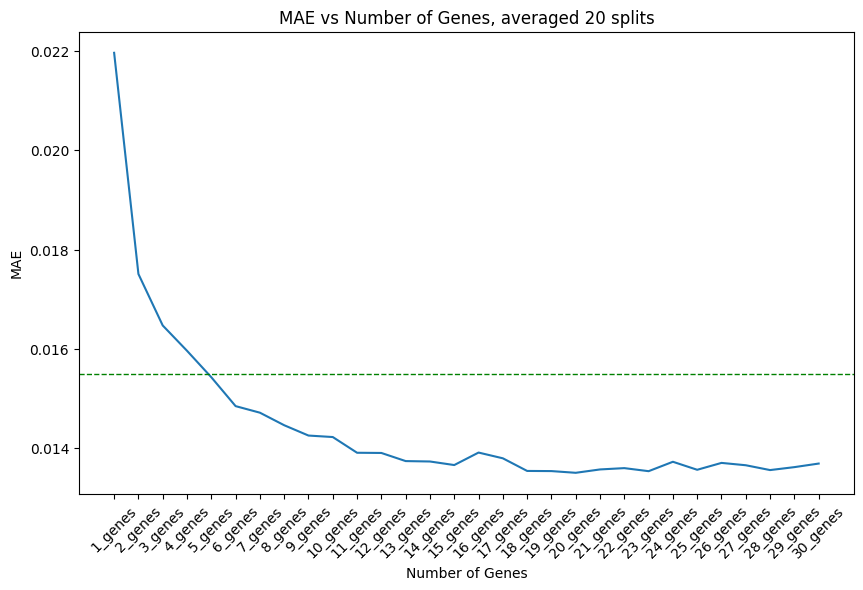

In [351]:
mae_all_mean = mae_all_df.mean(axis=0)
plt.figure(figsize=(10, 6))
plt.plot(mae_all_df.columns, mae_all_mean.values, label=idx)
plt.xlabel('Number of Genes')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.axhline(y=0.0155, color='green', linestyle='--', linewidth=1)
plt.title('MAE vs Number of Genes, averaged 20 splits')
plt.show()

Out mean MAE is lowest at 6 genes but then stays low and moves around within the range of noise until 30 genes without going up.  This gives us some leeway - we don't have to get the number exact to have a reliable model.  This suggests that we have a fair amount of redundancy in our model - it might only take 20 genes to make predictions, but it's not always the same 20 genes. Not only that, the specific genes probably very from dataset to dataset, so picking a specific gene list might limit our ability to generalize this model.

To test this assumption, the next step is to see if the model picks the same genes with different splits.

In [352]:
from collections import Counter
def count_gene_use(selected_gene_dict):
  all_genes = []
  for genes in selected_gene_dict.values():
    all_genes.extend(genes)
  gene_counts = Counter(all_genes)
  df = pd.DataFrame.from_dict(gene_counts, orient='index', columns=['count'])
  return df.sort_values(by='count', ascending=False)

In [353]:
gene_counts_24_df = count_gene_use(selected_gene_24)
gene_counts_10_df = count_gene_use(selected_gene_10)
gene_counts_6_df = count_gene_use(selected_gene_6)

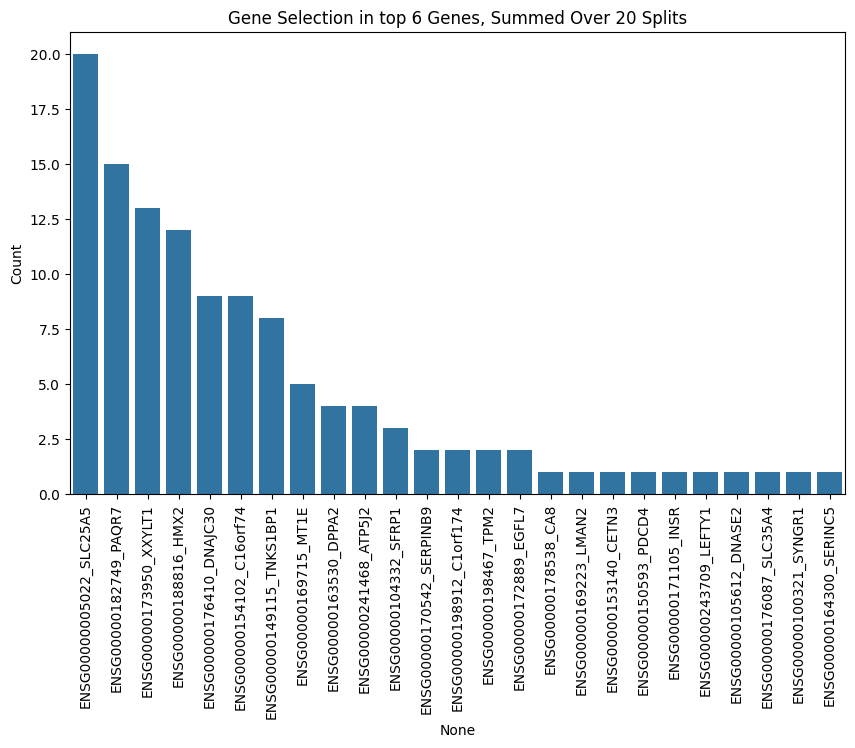

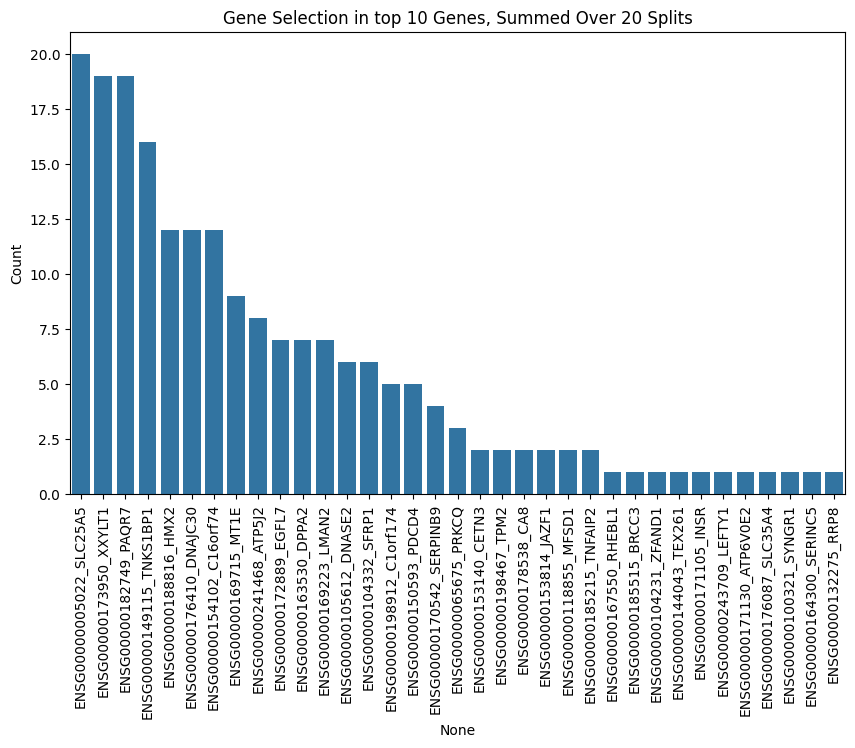

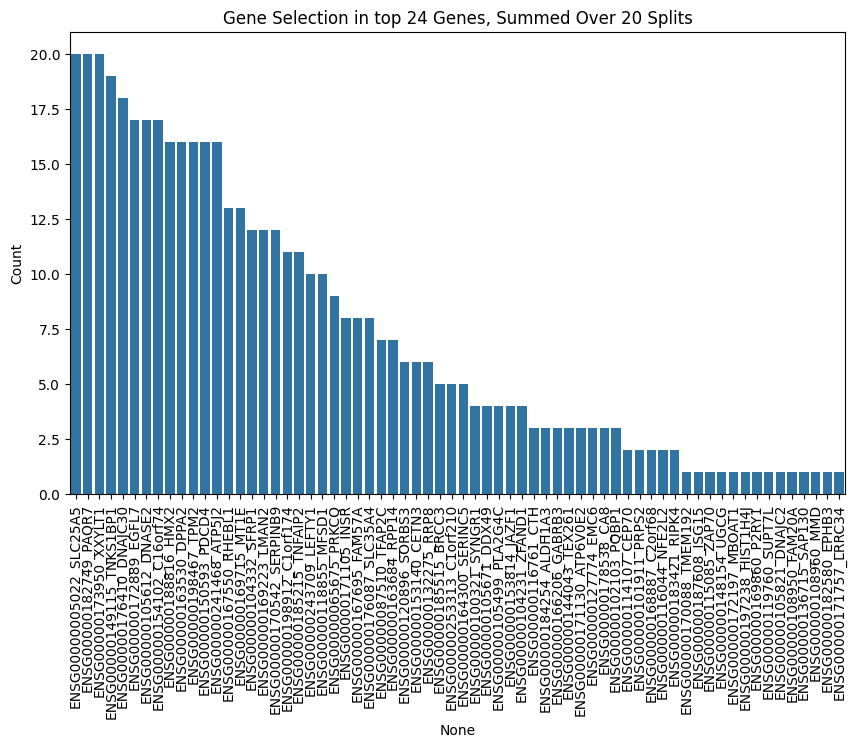

In [354]:
for k, group in [(6, gene_counts_6_df), (10, gene_counts_10_df), (24, gene_counts_24_df)]:
  plt.figure(figsize=(10, 6))
  sns.barplot(data=group, x=group.index, y='count')
  plt.title(f"Gene Selection in top {k} Genes, Summed Over 20 Splits")
  plt.ylabel("Count")
  plt.xticks(rotation=90)
  plt.show()

In [355]:
print(f'Number of genes in most important 24 genes over 20 splits: {gene_counts_24_df.shape[0]}')
print(f'Number of genes in most important 10 genes over 20 splits: {gene_counts_10_df.shape[0]}')
print(f'Number of genes in most important 6 genes over 20 splits: {gene_counts_6_df.shape[0]}')

Number of genes in most important 24 genes over 20 splits: 66
Number of genes in most important 10 genes over 20 splits: 35
Number of genes in most important 6 genes over 20 splits: 25


These results show us two things:

1) Out lists of 'top 6 genes' has 28 genes in it.  This confirms that there is redundancy in our model such that different sets of genes can be used to make predictions.
2) Some genes are more likely to be selected than others.  Some genes, like SLC25A5 are selected as being very important almost every time.  

Let's look at the overlap between the ~20 of genes most commonly in the top 24 and the genes in the top 10 or top 6.

In [356]:
top_22 = gene_counts_24_df[gene_counts_24_df['count'] >= 10]
common_10 = list(set(gene_counts_10_df.index) & set(top_22.index))
common_6 = list(set(gene_counts_6_df.index) & set(top_22.index))
print(f'Number of genes with 10+ selections in most important 24 genes: {len(top_22)}')
print(f'Number of common genes also in top 10 most important genes: {len(common_10)}')
print(f'Number of common genes also in top 6 most important genes: {len(common_6)}')

Number of genes with 10+ selections in most important 24 genes: 22
Number of common genes also in top 10 most important genes: 22
Number of common genes also in top 6 most important genes: 19


### Comparing Maual or Automated Gene Selection

This shows us that there is a group of 20 genes at the top that are selected most often.  Let's try building a model with just those 22 genes over multiple splits.

The above plots show our average model success if we allow the model to pick it's own genes for each split. The question is whether it is better to use a set of common genes (our top_22) or allow the model to select any 22 genes.  We will now compare these two options over 20 splits each.

First, with our definied list of 22 genes.

####Manual Gene Selection

In [357]:
top_22genes = list(top_22.index)
top_22genes

['ENSG00000005022_SLC25A5',
 'ENSG00000182749_PAQR7',
 'ENSG00000173950_XXYLT1',
 'ENSG00000149115_TNKS1BP1',
 'ENSG00000176410_DNAJC30',
 'ENSG00000172889_EGFL7',
 'ENSG00000105612_DNASE2',
 'ENSG00000154102_C16orf74',
 'ENSG00000188816_HMX2',
 'ENSG00000163530_DPPA2',
 'ENSG00000198467_TPM2',
 'ENSG00000150593_PDCD4',
 'ENSG00000241468_ATP5J2',
 'ENSG00000167550_RHEBL1',
 'ENSG00000169715_MT1E',
 'ENSG00000104332_SFRP1',
 'ENSG00000169223_LMAN2',
 'ENSG00000170542_SERPINB9',
 'ENSG00000198912_C1orf174',
 'ENSG00000185215_TNFAIP2',
 'ENSG00000243709_LEFTY1',
 'ENSG00000118855_MFSD1']

In [358]:
#Verify that donor_adata.layers["counts"] is still raw counts by finding the max value (should be large)
donor_adata.layers["counts"].max()

np.float64(4477677.06230918)

In [359]:
#Remake the dataset with the top 22 genes for safety
donor_rank_22 = donor_adata.copy()
donor_rank_22.X = donor_adata.layers["counts"]
donor_rank_22 = donor_adata[:, top_22genes].copy()

In [360]:
n_splits = 20
mae_all = {}
importances_dict = {}
X_22 = pd.DataFrame(donor_rank_22.X, columns=donor_rank_22.var_names, index=donor_rank_22.obs_names)
y_pr = donor_adata.obs['pseudorank']

for seed in range(n_splits):
  print(f"Starting seed {seed}")
  X_train, X_test, y_train, y_test = train_test_split(X_22, y_pr, test_size=0.2, random_state=seed) #Make Split
  X_train = normalize_log(X_train)
  X_test = normalize_log(X_test)
  full_model = CatBoostRegressor(verbose=0) #Fit full model
  full_model.fit(X_train, y_train)
  importances = full_model.get_feature_importance()
  importances_series = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
  importances_dict[seed] = pd.Series(100 * importances / importances.sum(), index=X_train.columns).sort_values(ascending=False)
  mae_split = []
  for i in range(1, 23, 1):
    selected_features = importances_series.head(i).index #Select top k genes
    X_train_short = X_train[selected_features]
    X_test_short = X_test[selected_features]
    model = CatBoostRegressor(verbose=0)
    model.fit(X_train_short, y_train)
    y_pred = model.predict(X_test_short)
    mae = mean_absolute_error(y_test, y_pred) #collect MAE
    mae_split.append(mae)
  mae_all[seed] = mae_split

Starting seed 0
Starting seed 1
Starting seed 2
Starting seed 3
Starting seed 4
Starting seed 5
Starting seed 6
Starting seed 7
Starting seed 8
Starting seed 9
Starting seed 10
Starting seed 11
Starting seed 12
Starting seed 13
Starting seed 14
Starting seed 15
Starting seed 16
Starting seed 17
Starting seed 18
Starting seed 19


In [361]:
mae_22_df = pd.DataFrame.from_dict(mae_all, orient='index')
mae_22_df.index = [f"split_{i+1}" for i in mae_22_df.index]
mae_22_df.columns = [f"{i+1}_genes" for i in range(22)]

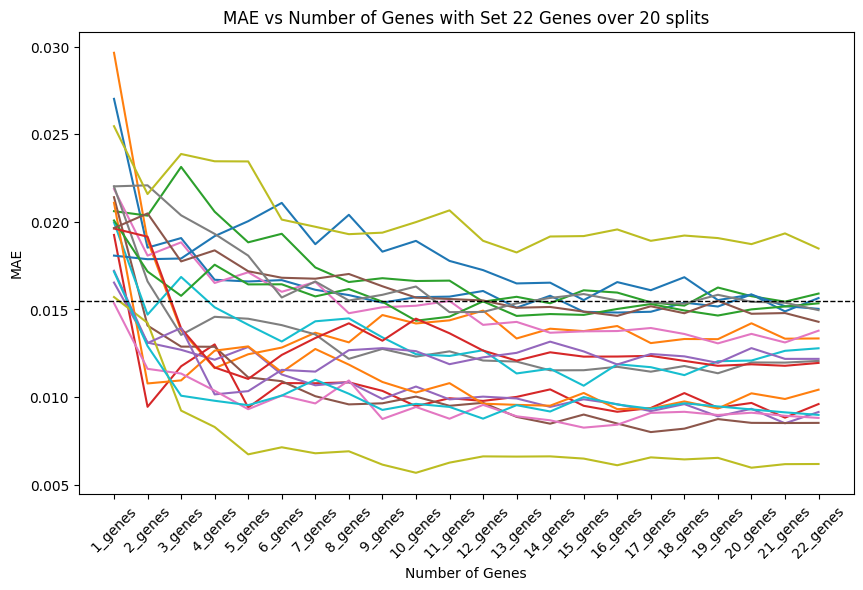

In [362]:
plt.figure(figsize=(10, 6))
for idx, row in mae_22_df.iterrows():
  plt.plot(mae_22_df.columns, row.values, label=idx)
plt.xlabel('Number of Genes')
plt.axhline(y=0.0155, color='black', linestyle='--', linewidth=1)
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.title('MAE vs Number of Genes with Set 22 Genes over 20 splits')
plt.show()


We can also look at the relative importance of each gene, averaged over the 20 splits.

In [363]:
importances_df = pd.DataFrame.from_dict(importances_dict)
importances_df_mean = importances_df.mean(axis=1).sort_values(ascending=False)
importances_df_mean


,0
Unnamed: 0,
ENSG00000176410_DNAJC30,13.196282
ENSG00000188816_HMX2,7.713874
ENSG00000198467_TPM2,6.927733
ENSG00000149115_TNKS1BP1,6.463602
ENSG00000154102_C16orf74,5.860298
ENSG00000169715_MT1E,5.281428
ENSG00000170542_SERPINB9,5.062366
ENSG00000173950_XXYLT1,4.964286
ENSG00000005022_SLC25A5,4.848637


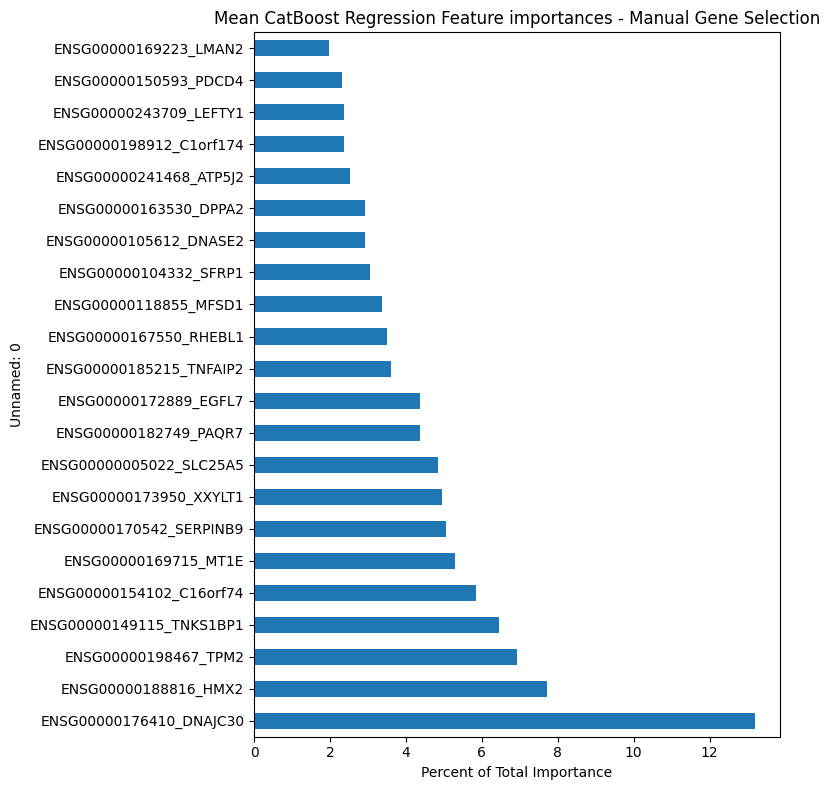

In [364]:
#Plot feature importances
fig, ax = plt.subplots(figsize=(8,8))
importances_df_mean.plot.barh(ax=ax)
ax.set_title("Mean CatBoost Regression Feature importances - Manual Gene Selection")
ax.set_xlabel("Percent of Total Importance")
fig.tight_layout()
plt.show()

####Automated Gene Selection

Now let's try again with setting the model to pick any 22 genes from out list of 100.

In [377]:
#Verify that donor_rank_100.layers["counts"] is still raw counts by finding the max value (should be large)
donor_rank_100.layers["counts"].max()

np.float64(759411.0718874728)

In [367]:
n_splits = 20
mae_all = {}
importances_dict = {}
donor_rank_100_V2 = donor_rank_100.copy()
donor_rank_100_V2.X = donor_rank_100_V2.layers["counts"]
#I had to move the normalization out of the loop and switch back the Scanpy based normalization to prevent the code from hanging.
#Normalization is by row, so no data leakage will occur.
sc.pp.normalize_total(donor_rank_100_V2, target_sum=1e4)
sc.pp.log1p(donor_rank_100_V2)
X_100 = pd.DataFrame(donor_rank_100_V2.X, columns=donor_rank_100_V2.var_names, index=donor_rank_100_V2.obs_names)
y_pr = donor_adata.obs['pseudorank']

for seed in range(n_splits):
  print(f"Starting seed {seed}")
  X_train, X_test, y_train, y_test = train_test_split(X_100, y_pr, test_size=0.2, random_state=seed) #Make Split
  selector_model = CatBoostRegressor(verbose=0, thread_count=4) #Fit full model
  summary = selector_model.select_features(
        X_train,
        y_train,
        features_for_select=list(range(X_train.shape[1])),  #select genes from entire list of 100
        num_features_to_select=22, #Optimal number of genes
        algorithm='RecursiveByShapValues',
        steps=5,
        logging_level='Silent',
    )
  selected_features = X_train.columns[summary['selected_features']]
  full_model = CatBoostRegressor(verbose=0)
  full_model.fit(X_train[selected_features], y_train)
  importances = full_model.get_feature_importance()
  importances_series = pd.Series(importances, index=selected_features).sort_values(ascending=False)
  importances_dict[seed] = 100 * importances / importances.sum()
  mae_split = []
  for i in range(1, 23, 1):
    selected_features_short = selected_features[:i] #Select top k genes
    X_train_short = X_train[selected_features_short]
    X_test_short = X_test[selected_features_short]
    model = CatBoostRegressor(verbose=0)
    model.fit(X_train_short, y_train)
    y_pred = model.predict(X_test_short)
    mae = mean_absolute_error(y_test, y_pred) #collect MAE
    mae_split.append(mae)
  mae_all[seed] = mae_split

Starting seed 0
Starting seed 1
Starting seed 2
Starting seed 3
Starting seed 4
Starting seed 5
Starting seed 6
Starting seed 7
Starting seed 8
Starting seed 9
Starting seed 10
Starting seed 11
Starting seed 12
Starting seed 13
Starting seed 14
Starting seed 15
Starting seed 16
Starting seed 17
Starting seed 18
Starting seed 19


Note: I am aware of the warning that adata.X has already been normalized. This was thoroughly investigated and the data is still in the orignal form that was found on the raw_counts.csv file. I think the warning is being triggered by the decimal points that are not normally present in raw RNAseq data, but this is most likely present due to some step quaility control step by Cuomo et al.

In [371]:
mae_auto_df = pd.DataFrame.from_dict(mae_all, orient='index')
mae_auto_df.index = [f"split_{i+1}" for i in mae_auto_df.index]
mae_auto_df.columns = [f"{i+1}_genes" for i in range(22)]

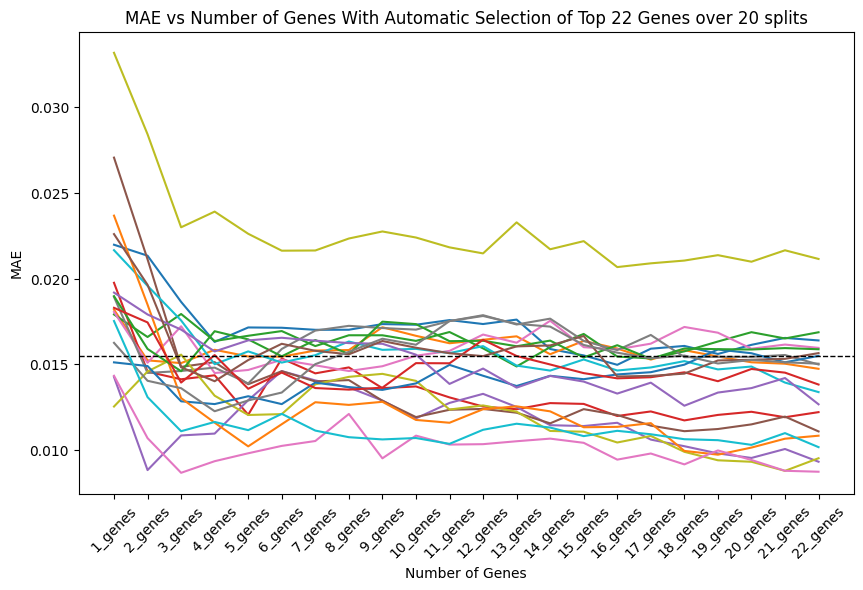

In [372]:
plt.figure(figsize=(10, 6))
for idx, row in mae_auto_df.iterrows():
  plt.plot(mae_auto_df.columns, row.values, label=idx)
plt.xlabel('Number of Genes')
plt.axhline(y=0.0155, color='black', linestyle='--', linewidth=1)
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.title('MAE vs Number of Genes With Automatic Selection of Top 22 Genes over 20 splits')
plt.show()


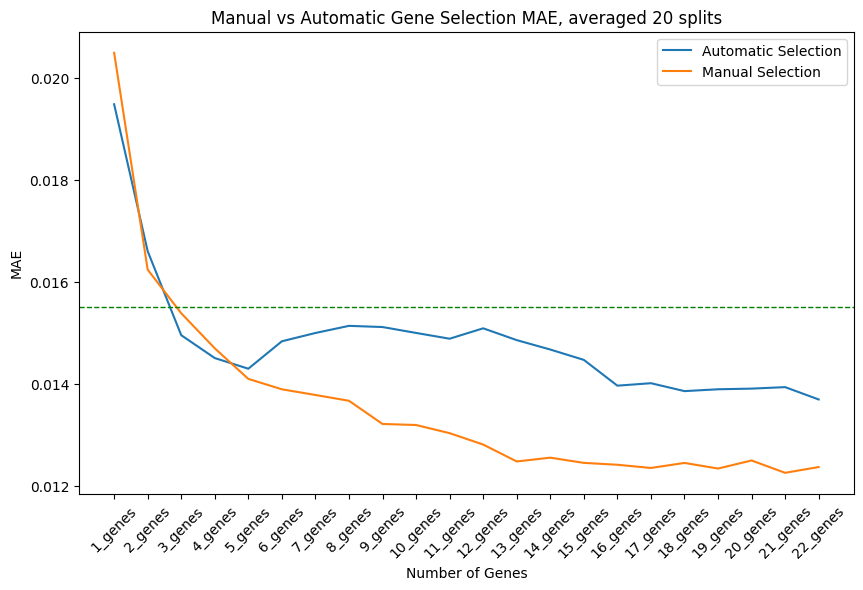

In [373]:
mae_22_mean = mae_22_df.mean(axis=0)
mae_auto_mean = mae_auto_df.mean(axis=0)
plt.figure(figsize=(10, 6))
plt.plot(mae_auto_df.columns, mae_auto_mean.values, label='Automatic Selection')
plt.plot(mae_22_df.columns, mae_22_mean.values, label='Manual Selection')
plt.xlabel('Number of Genes')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.axhline(y=0.0155, color='green', linestyle='--', linewidth=1)
plt.title('Manual vs Automatic Gene Selection MAE, averaged 20 splits')
plt.legend()
plt.show()

In [374]:
importances_df_auto = pd.DataFrame.from_dict(importances_dict)
importances_df_auto_mean = importances_df.mean(axis=1).sort_values(ascending=False)

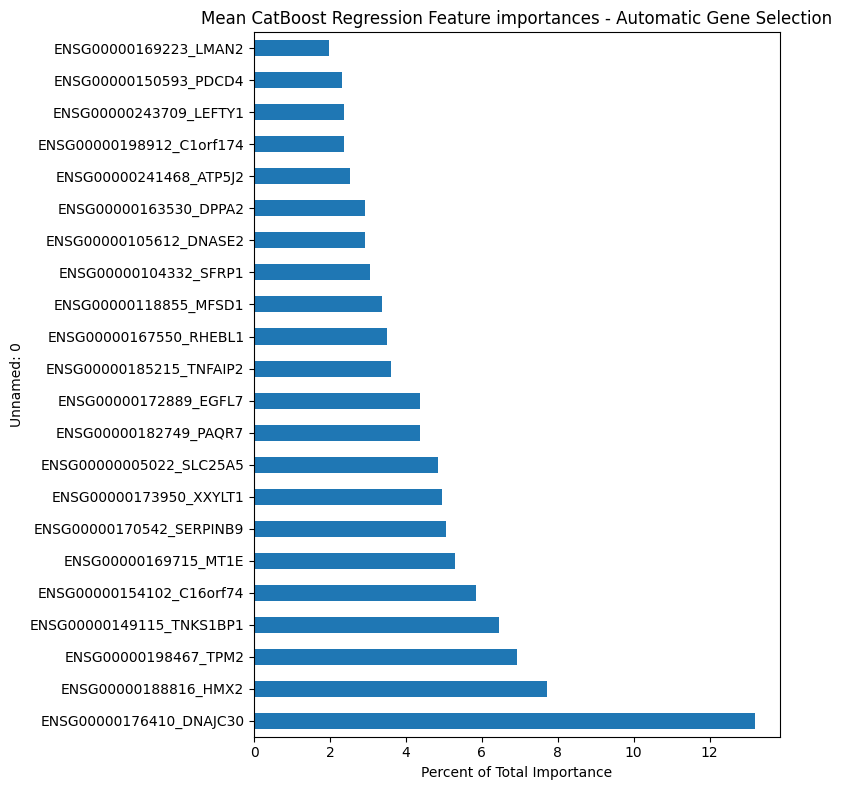

In [375]:
#Plot feature importances
fig, ax = plt.subplots(figsize=(8,8))
importances_df_auto_mean.plot.barh(ax=ax)
ax.set_title("Mean CatBoost Regression Feature importances - Automatic Gene Selection")
ax.set_xlabel("Percent of Total Importance")
fig.tight_layout()
plt.show()

This comparison between manually selecting specific genes and letting the model automatically select genes for each split shows us that we get a lower error when we manually choose the genes if we use 7 or more genes.  If we wanted to use fewer than 7 genes, the automatic selection is superior.

This does not mean that manual gene selection makes the best model for new data.  New data will be from different RNAseq batches and might get better predictions from a different set of genes than what we used here.  Without testing this on new datasets, using manual selection in our final model is risky.  I recommend making a model that is based on our 22 genes, and a model able to do gene selction based on the specifics of the new dataset.

The last question for our model with automatic gene selection is whether we should choose 22 genes, or up to 22 genes. I will compare these two scenarios.

In [ ]:
n_splits = 20
shap_threshold = [.01, .005, .001, .0005, .0001] #The best threshold for Shap values is unknown, so we will try a few
mae_shap = {}
selected_genes_dict = {}
donor_rank_100_shap = donor_rank_100.copy()
donor_rank_100_shap.X = donor_rank_100_shap.layers["counts"].copy()
X = pd.DataFrame(donor_rank_100_shap.X, columns=donor_rank_100_shap.var_names, index=donor_rank_100_shap.obs_names)
for shap_threshold in shap_threshold:
  mae_splits = {}
  selected_genes_len = {}
  for seed in range(n_splits):
    X_train, X_test, y_train, y_test = train_test_split(X, y_pr, test_size=0.2, random_state=seed) #Make Split
    X_train = normalize_log(X_train)
    X_test = normalize_log(X_test)
    train_pool = Pool(X_train, y_train)
    selector_model = CatBoostRegressor(loss_function = 'MAE', verbose=0) #Fit full model
    selector_model.fit(X_train, y_train)
    shap_values = selector_model.get_feature_importance(data=train_pool, type='ShapValues') #Calculate shap values
    feature_importance = np.abs(shap_values).mean(axis=0) #Calculate feature importance
    sorted_features = sorted(zip(X_train.columns, feature_importance), key=lambda x: x[1], reverse=True)
    selected_genes = [f for f,val in zip(X_train.columns, feature_importance) if val > shap_threshold] #fine genes above threshold
    selected_genes = selected_genes[:22]
    if len(selected_genes) == 0:
      selected_genes = [f for f, _ in sorted_features[:5]]
    selected_genes_len[seed] = len(selected_genes)
    model_final = CatBoostRegressor(loss_function = 'MAE', verbose=0) #train new model on selected_genes
    model_final.fit(X_train[selected_genes], y_train)
    y_pred = model_final.predict(X_test[selected_genes])
    mae_splits[seed] = mean_absolute_error(y_test, y_pred)
  mae_shap[shap_threshold] = mae_splits
  selected_genes_dict[shap_threshold] = selected_genes_len

In [381]:
mae_shap_df = pd.DataFrame(mae_shap)
mae_shap_df.index = [f"split_{i+1}" for i in mae_shap_df.index]
mae_shap_df.columns = ['Shap_.01', 'Shap_.005', 'Shap_.001', 'Shap_.0005', 'Shap_.0001']
mae_shap_df_mean = mae_shap_df.mean(axis=0).to_frame(name='MAE')
mae_shap_df_std = mae_shap_df.std(axis=0).to_frame(name='Std')

In [382]:
mae_shap_df_mean

,MAE
Shap_.01,0.015432
Shap_.005,0.015432
Shap_.001,0.016479
Shap_.0005,0.013266
Shap_.0001,0.013903


In [383]:
manual_mean = mae_22_df.loc[:, '22_genes'].mean()
manual_std = mae_22_df.loc[:, '22_genes'].std()
auto_mean = mae_auto_df.loc[:, '22_genes'].mean()
auto_std = mae_auto_df.loc[:, '22_genes'].mean()

In [384]:
means = [manual_mean, auto_mean]
stds = [manual_std, auto_std]
means_df = pd.concat([pd.DataFrame(means, index=['Manual', 'Automatic_RFE'], columns=['MAE']), mae_shap_df_mean])
stds_df = pd.concat([pd.DataFrame(stds, index=['Manual', 'Automatic_RFE'], columns=['Std']), mae_shap_df_std])
comp_df = pd.concat([means_df, stds_df], axis=1)

In [385]:
comp_df

,MAE,Std
Manual,0.012376,0.003156
Automatic_RFE,0.013699,0.013699
Shap_.01,0.015432,0.003224
Shap_.005,0.015432,0.003224
Shap_.001,0.016479,0.003773
Shap_.0005,0.013266,0.002673
Shap_.0001,0.013903,0.002948


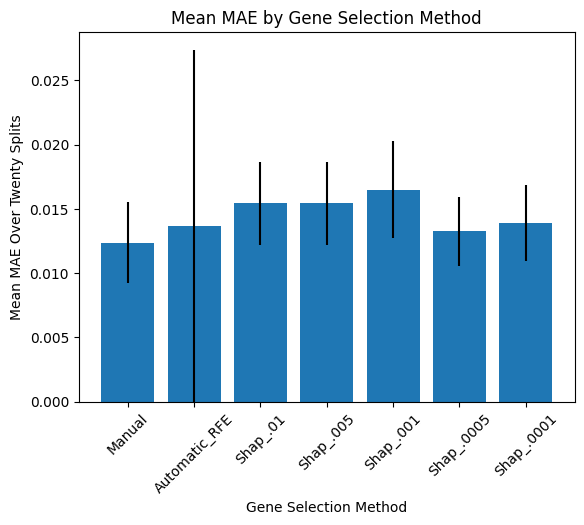

In [386]:
plt.bar(data=comp_df, x=comp_df.index, height='MAE', yerr='Std')
plt.title('Mean MAE by Gene Selection Method')
plt.ylabel('Mean MAE Over Twenty Splits')
plt.xlabel('Gene Selection Method')
plt.xticks(rotation=45)
plt.show()

From this we can see that the Recusive Feature Elimination that we used for the first model with Automatic Gene Selection is highly variable.  Gene selction through Shap values is much more stable accross splits, so we will use this for the final model with gene selection.

These resutls suggest that the optimal Shap Threshold is .0005, as this has the lowest error of the models with automatic gene selection. We are looking for a threshold that selects almost 22 genes, but not quite that many if there are not enough genes making the cutoff for that split.  We can confirm if .0005 fits this description by looking at the number of selected genes.

In [387]:
selected_genes_len_df = pd.DataFrame(selected_genes_dict)
selected_genes_len_df.index = [f"split_{i+1}" for i in selected_genes_len_df.index]
selected_genes_len_df.columns = ['Shap_.01', 'Shap_.005', 'Shap_.001', 'Shap_.0005', 'Shap_.0001']
selected_genes_len_df_mean = selected_genes_len_df.mean(axis=0).to_frame(name='MAE')
selected_genes_len_df_std = selected_genes_len_df.std(axis=0).to_frame(name='Std')

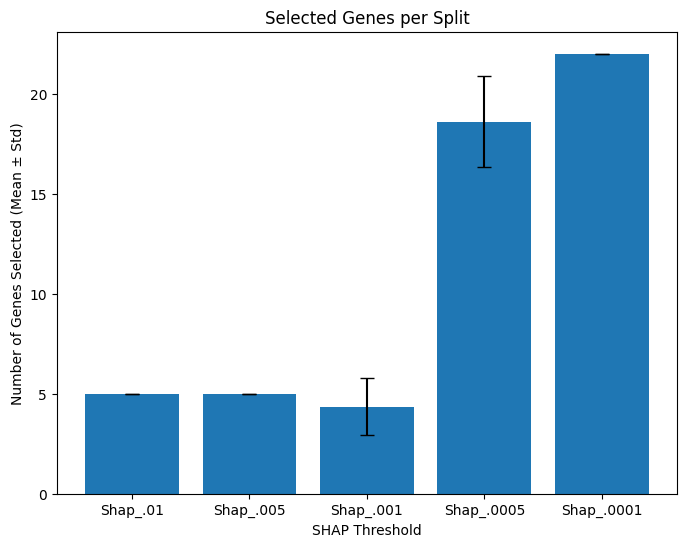

In [388]:
x_labels = selected_genes_len_df_mean.index
heights = selected_genes_len_df_mean['MAE']
yerr = selected_genes_len_df_std['Std']

plt.figure(figsize=(8,6))
plt.bar(x_labels, heights, yerr=yerr, capsize=5)
plt.ylabel('Number of Genes Selected (Mean ± Std)')
plt.xlabel('SHAP Threshold')
plt.title('Selected Genes per Split')
plt.show()

This confirms our suspicions that .0005 results in almost 22 genes being selected depending on their importance.  We will use this threshold in our final model.

##Final Model

In our final model, we must build something that will be as reslient as possible to differences between new datasets, even if that means sacrificing MAE with the existing dataset.  For that reason, I will use recursive feature elimination to select genes based on the split, rather than using the genes we have already identified for our split with random state 42.

In [389]:
#Final Model with Manual Gene Selection
X_22 = pd.DataFrame(donor_rank_22.X, columns=donor_rank_22.var_names, index=donor_rank_22.obs_names)
y_pr = donor_adata.obs['pseudorank']

X_train, X_test, y_train, y_test = train_test_split(X_22, y_pr, test_size=0.2, random_state=seed)
X_train = normalize_log(X_train)
X_test = normalize_log(X_test)
CB_final_manual = CatBoostRegressor(verbose=0)
CB_final_manual.fit(X_train, y_train)
y_pred_manual = CB_final_manual.predict(X_test)
mae_manual = mean_absolute_error(y_test, y_pred_manual )

In [390]:
X_100 = pd.DataFrame(donor_rank_100.X, columns=donor_rank_100.var_names, index=donor_rank_100.obs_names)
y_pr = donor_adata.obs['pseudorank']
shap_threshold = .0005

X_train, X_test, y_train, y_test = train_test_split(X_100, y_pr, test_size=0.2, random_state=seed) #Perform Split
X_train = normalize_log(X_train)
X_test = normalize_log(X_test)

train_pool = Pool(X_train, y_train)
selector_model = CatBoostRegressor(loss_function = 'MAE', verbose=0) #Build Selector Model for calculating Shap Values
selector_model.fit(X_train, y_train)
shap_values = selector_model.get_feature_importance(data=train_pool, type='ShapValues') #Calculate shap values
feature_importance = np.abs(shap_values).mean(axis=0) #Calculate feature importance
sorted_features = sorted(zip(X_train.columns, feature_importance), key=lambda x: x[1], reverse=True)
selected_genes = [f for f,val in zip(X_train.columns, feature_importance) if val > shap_threshold] #fine genes above threshold
selected_genes = selected_genes[:22]
if len(selected_genes) == 0:
  selected_genes = [f for f, _ in sorted_features[:5]]
CB_final_auto = CatBoostRegressor(loss_function = 'MAE', verbose=0) #train new model on selected_genes
CB_final_auto.fit(X_train[selected_genes], y_train)
y_pred_auto = CB_final_auto.predict(X_test[selected_genes])
mae_auto = mean_absolute_error(y_test, y_pred_auto)

In [391]:
print(f'MAE for Manual Gene Selection: {mae_manual}')
print(f'MAE for Automatic Gene Selection: {mae_auto}')

MAE for Manual Gene Selection: 0.009139791180862196
MAE for Automatic Gene Selection: 0.009567536456934825


In [392]:
#Save final dataset used for manual and automatic models
donor_rank_100.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/donor_100_automatic.h5ad")
donor_rank_22.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/donor_22_manual.h5ad")

In [393]:
CB_final_manual.save_model("/content/drive/MyDrive/Springboard/Capstone3_iPSC/CB_final_manual.cbm")
CB_final_auto.save_model("/content/drive/MyDrive/Springboard/Capstone3_iPSC/CB_final_automatic.cbm")